In [1]:
import csv
import math
import gurobipy as gp
from gurobipy import GRB
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker
import numpy as np
import pandas as pd

df = pd.read_excel('Master DataFrame - Opioid.xlsx', sheet_name="Normalized")

In [2]:
df.to_csv('Master DataFrame.csv', index=False)

## Baseline Models

### Load Data

In [3]:


# ─────────────────────────────────────────────────────────────────────────────
# 0.  Load data
# ─────────────────────────────────────────────────────────────────────────────
METRIC_COLS = {
    "overdose":        "all drug overdose share",
    "hospitalization": "hospitalization share",
    "naloxone":        "nalxone share",
    "mme":             "MME adjusted share",
}

counties = []
shares   = {}   # shares[county][metric]
a_min    = {}   # from CSV column a_min_i (min over 5 metrics incl. population)
a_max    = {}   # from CSV column a_max_i (max over 5 metrics incl. population)
meta     = {}   # rural_urban_binary, health_rank_binary

with open("Master DataFrame.csv", newline="", encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)
    reader.fieldnames = [h.strip() for h in reader.fieldnames]
    for row in reader:
        row = {k.strip(): v.strip() for k, v in row.items()}
        c = row["County"]
        counties.append(c)
        shares[c] = {m: float(row[col]) for m, col in METRIC_COLS.items()}
        a_min[c]  = float(row["a_min_i"])
        a_max[c]  = float(row["a_max_i"])
        meta[c]   = {
            "rural":  int(row["rural_urban_binary"]),   # 1=rural, 0=urban
            "health": int(row["health_rank_binary"]),   # 1=low-ranking, 0=high-ranking
            "income": int(row['income_rank_binary'])    # 1=below median, 0=above median
        }

METRICS = list(METRIC_COLS.keys())
N       = len(counties)

### Formula-Based Model

In [4]:
import csv

counties = []
shares = {}

with open("Master DataFrame.csv", newline="", encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)
    reader.fieldnames = [name.strip() for name in reader.fieldnames]

    for row in reader:
        clean_row = {key.strip(): value.strip() for key, value in row.items()}

        county = clean_row["County"]
        counties.append(county)

        shares[county] = {
            "overdose": float(clean_row["all drug overdose share"]),
            "hospitalization": float(clean_row["hospitalization share"]),
            "naloxone": float(clean_row["nalxone share"]),
            "mme": float(clean_row["MME adjusted share"])
        }

allocation = {}
for c in counties:
    allocation[c] = (
        0.4 * shares[c]["overdose"]
        + 0.2 * shares[c]["hospitalization"]
        + 0.2 * shares[c]["naloxone"]
        + 0.2 * shares[c]["mme"]
    )

print("Sum of allocations =", sum(allocation[c] for c in counties))
print()

for c in counties:
    print(f"{c}: {allocation[c]:.10f}")

with open("formula_based_results.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["County", "Formula_Based_Allocation"])
    for c in counties:
        writer.writerow([c, allocation[c]])

print("\nResults written to formula_based_results.csv")

Sum of allocations = 1.0000000000000002

Adams: 0.0034405010
Allegheny: 0.1152408780
Armstrong: 0.0060629693
Beaver: 0.0127416450
Bedford: 0.0019196624
Berks: 0.0189087342
Blair: 0.0080748341
Bradford: 0.0022495068
Bucks: 0.0580258464
Butler: 0.0136937207
Cambria: 0.0158709622
Cameron: 0.0007181842
Carbon: 0.0064375060
Centre: 0.0024996169
Chester: 0.0222951160
Clarion: 0.0014650653
Clearfield: 0.0029881480
Clinton: 0.0010458564
Columbia: 0.0032831353
Crawford: 0.0067058660
Cumberland: 0.0104763628
Dauphin: 0.0161064818
Delaware: 0.0646833724
Elk: 0.0016806331
Erie: 0.0205139450
Fayette: 0.0134825721
Forest: 0.0004912605
Franklin: 0.0051438222
Fulton: 0.0007720821
Greene: 0.0020506267
Huntingdon: 0.0017896762
Indiana: 0.0068281271
Jefferson: 0.0018893232
Juniata: 0.0006057023
Lackawanna: 0.0139279841
Lancaster: 0.0226646632
Lawrence: 0.0098903099
Lebanon: 0.0060344126
Lehigh: 0.0210731386
Luzerne: 0.0328223105
Lycoming: 0.0064217062
McKean: 0.0018028156
Mercer: 0.0093134348
Mifflin: 0.

### Mini-max Regret

In [5]:


# ── Minimax-regret ───────────────────────────────────────────────
import gurobipy as gp
from gurobipy import GRB

minMax_model = gp.Model("minimax_regret")
minMax_model.Params.OutputFlag = 0

x = {c: minMax_model.addVar(lb=a_min[c], ub=a_max[c]) for c in counties}
r = minMax_model.addVar(lb=0.0)

minMax_model.addConstr(gp.quicksum(x[c] for c in counties) == 1)
for c in counties:
    minMax_model.addConstr(r >= 1 - x[c] / a_max[c])  # a_max now includes population

minMax_model.setObjective(r, GRB.MINIMIZE)
minMax_model.optimize()


if minMax_model.Status == GRB.OPTIMAL:
    allocation = {c: x[c].X for c in counties}
    regret = {c: 1 - allocation[c] / a_max[c] for c in counties}

    print("\nOptimal objective value R* =", minMax_model.ObjVal)
    print("Sum of allocations =", sum(allocation[c] for c in counties))
    print()

    for c in counties:
        print(
            f"{c}: allocation = {allocation[c]:.10f}, "
            f"a_min = {a_min[c]:.10f}, "
            f"a_max = {a_max[c]:.10f}, "
            f"regret = {regret[c]:.10f}"
        )

    with open("minmax_regret_results.csv", "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["County", "Allocation", "a_min", "a_max", "County_Regret"])
        for c in counties:
            writer.writerow([c, allocation[c], a_min[c], a_max[c], regret[c]])

    print("\nResults written to minmax_regret_results.csv")
else:
    print("No optimal solution found. Status =", minMax_model.Status)

Set parameter Username
Set parameter LicenseID to value 2767627
Academic license - for non-commercial use only - expires 2027-01-19

Optimal objective value R* = 0.22719944238136477
Sum of allocations = 0.9999999999999996

Adams: allocation = 0.0036065119, a_min = 0.0024601906, a_max = 0.0046668081, regret = 0.2271994424
Allegheny: allocation = 0.1043424165, a_min = 0.0850025758, a_max = 0.1350185575, regret = 0.2271994424
Armstrong: allocation = 0.0056007650, a_min = 0.0026970514, a_max = 0.0072473615, regret = 0.2271994424
Beaver: allocation = 0.0134093581, a_min = 0.0067709901, a_max = 0.0173516414, regret = 0.2271994424
Bedford: allocation = 0.0019952725, a_min = 0.0013541980, a_max = 0.0025818725, regret = 0.2271994424
Berks: allocation = 0.0185477754, a_min = 0.0105043442, a_max = 0.0240007273, regret = 0.2271994424
Blair: allocation = 0.0071247137, a_min = 0.0063638292, a_max = 0.0092193433, regret = 0.2271994424
Bradford: allocation = 0.0023803251, a_min = 0.0012538870, a_max =

### Min Deviation

In [6]:

minDev_model = gp.Model("min_deviation_SAP")

x = {
    c: minDev_model.addVar(lb=a_min[c], ub=a_max[c], name=f"x_{c}")
    for c in counties
}

minDev_model.addConstr(gp.quicksum(x[c] for c in counties) == 1)

obj_terms = []
for c in counties:
    for m in METRICS:
        a_im = shares[c][m]
        if a_im > 0:
            obj_terms.append((1 - x[c] / a_im) * (1 - x[c] / a_im))

minDev_model.setObjective((1.0 / N) * gp.quicksum(obj_terms), GRB.MINIMIZE)
minDev_model.optimize()

if minDev_model.Status == GRB.OPTIMAL:
    allocation = {c: x[c].X for c in counties}

    print("Optimal objective value D* =", minDev_model.ObjVal)
    print("Sum of allocations =", sum(allocation[c] for c in counties))
    print()

    for c in counties:
        print(f"{c}: {allocation[c]:.10f}")

    with open("min_deviation_results.csv", "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["County", "Min_Deviation_Allocation"])
        for c in counties:
            writer.writerow([c, allocation[c]])

    print("\nResults written to min_deviation_results.csv")
else:
    print("No optimal solution found. Status =", minDev_model.Status)

Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[x86] - Darwin 23.3.0 23D60)

CPU model: Intel(R) Core(TM) i9-9980HK CPU @ 2.40GHz
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 1 rows, 67 columns and 67 nonzeros (Min)
Model fingerprint: 0x0e288ea0
Model has 67 linear objective coefficients and an objective constant of 3.9850746268656714e+00
Model has 67 quadratic objective terms
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e-01, 4e+02]
  QObjective range [2e+00, 1e+06]
  Bounds range     [2e-04, 3e-01]
  RHS range        [1e+00, 1e+00]
Presolve time: 0.01s
Presolved: 1 rows, 67 columns, 67 nonzeros
Presolved model has 67 quadratic objective terms
Ordering time: 0.00s

Barrier statistics:
 AA' NZ     : 0.000e+00
 Factor NZ  : 1.000e+00
 Factor Ops : 1.000e+00 (less than 1 second per iteration)
 Threads    : 1

                  Objective                Residual
Iter       Primal          Dual

Comparison of settlement
allocation policies in three example
counties of (A) large, (B) medium,
and (C) small sizes

In [7]:
"""
Reproduce Figure 1 from Chen, Newton & Griffin (2025)
"Fair allocation strategies for opioid settlements"
"""

import csv
import math
import gurobipy as gp
from gurobipy import GRB
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker
import numpy as np
  

# ── 1. Formula-based allocation ───────────────────────────────────────────────
def formula_based():
    return {
        c: (  0.4 * shares[c]["overdose"]
            + 0.2 * shares[c]["hospitalization"]
            + 0.2 * shares[c]["naloxone"]
            + 0.2 * shares[c]["mme"])
        for c in counties
    }

# ── 2. Min-deviation (convex QP) ─────────────────────────────────────────────
def min_deviation():
    m = gp.Model("min_deviation")
    m.Params.OutputFlag = 0
    x = {c: m.addVar(lb=a_min[c], ub=a_max[c]) for c in counties}
    m.addConstr(gp.quicksum(x[c] for c in counties) == 1)
    obj = []
    for c in counties:
        for met in METRICS:
            a_im = shares[c][met]
            if a_im > 0:
                obj.append((1 - x[c] / a_im) * (1 - x[c] / a_im))
    m.setObjective((1.0 / N) * gp.quicksum(obj), GRB.MINIMIZE)
    m.optimize()
    return {c: x[c].X for c in counties}

# ── 3. Minimax-regret (LP) ───────────────────────────────────────────────────

def minimax_regret():
    m = gp.Model("minimax_regret")
    m.Params.OutputFlag = 0
    x = {c: m.addVar(lb=a_min[c], ub=a_max[c]) for c in counties}
    r = m.addVar(lb=0.0)
    m.addConstr(gp.quicksum(x[c] for c in counties) == 1)
    for c in counties:
        m.addConstr(r >= 1 - x[c] / a_max[c])
    m.setObjective(r, GRB.MINIMIZE)
    m.optimize()
    return {c: x[c].X for c in counties}

# ── 5. Run all policies ───────────────────────────────────────────────────────
print("Computing formula-based ...")
alloc_formula = formula_based()

print("Computing min-deviation ...")
alloc_dev = min_deviation()

print("Computing minimax-regret ...")
alloc_regret = minimax_regret()


# ── 6. Nine representative counties (as in paper) ────────────────────────────
GROUPS = {
    "Large":  ["Philadelphia", "Allegheny", "Montgomery"],
    "Medium": ["Lawrence", "Crawford", "Indiana"],
    "Small":  ["Forest", "Sullivan", "Cameron"],
}

# ── 7. Build bar chart ────────────────────────────────────────────────────────
POLICY_LABELS = ["Formula", "Min-\ndeviation", "Minimax-\nregret"]
N_POLICIES = len(POLICY_LABELS)

def get_alloc(policy_idx, county):
    if policy_idx == 0:
        return alloc_formula[county]
    if policy_idx == 1:
        return alloc_dev[county]
    if policy_idx == 2:
        return alloc_regret[county]

COLORS = ["#1f77b4", "#d62728", "#2ca02c"]   # blue, red, green
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

for ax_idx, (group_name, group_counties) in enumerate(GROUPS.items()):
    ax = axes[ax_idx]
    n_counties  = len(group_counties)
    bar_width   = 0.22
    group_gap   = 0.10
    total_width = n_counties * bar_width
    x_pos = np.arange(N_POLICIES) * (total_width + group_gap)
    offsets = [(i - (n_counties - 1) / 2) * bar_width for i in range(n_counties)]

    for ci, (county, color) in enumerate(zip(group_counties, COLORS)):
        heights = [get_alloc(pi, county) * 100 for pi in range(N_POLICIES)]
        ax.bar(x_pos + offsets[ci], heights, width=bar_width, color=color, label=county)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(POLICY_LABELS, fontsize=8)
    ax.set_ylabel("Allocation (%)", fontsize=9)
    ax.yaxis.set_major_formatter(
        matplotlib.ticker.FuncFormatter(lambda y, _: f"{y:.2f}%"))
    ax.legend(loc="upper right", fontsize=8)
    ax.set_title(
        f"({'ABC'[ax_idx]}) Comparison of allocation policies in three "
        f"{group_name.lower()} counties: "
        + ", ".join(group_counties) + ".",
        fontsize=9, loc="left")
    ax.tick_params(axis="x", labelsize=7.5)
    ax.grid(axis="y", linewidth=0.4, alpha=0.5)

plt.tight_layout(pad=2.0)
plt.savefig("figure1.png", dpi=180, bbox_inches="tight")
print("\nSaved figure1.png")

Computing formula-based ...
Computing min-deviation ...
Computing minimax-regret ...

Saved figure1.png


## Goal Program and θ Grid

In [8]:
"""
Goal-programming frontier analysis for opioid settlement allocation
Chen, Newton & Griffin (2025)

Objective:  min  θ * Fd(x,a)/D*  +  (1-θ) * Fr(x,a)/R* 
(minimizing the relative shortfall from the best achievable performance on each criteria)
Subject to: SAP constraints (sum=1, a_min <= x <= a_max)

The model is convex for all θ ∈ [0,1]:
  - Fd(x,a) is a convex quadratic (sum of squared relative deviations)
  - Fr(x,a) is linear (minimax via auxiliary variable r)
  - A non-negative weighted sum of convex functions is convex 

By dividing by the optimal values, both terms are normalized to be on the same scale. 
At the min-deviation solution, F_d/D* = 1.0
At the minimax-regret solution, Fr/R∗ = 1.0 exactly. 
Both normalized objectives have a minimum value of 1.0 by construction.

Fd​/D∗ tells you how many times worse than optimal your deviation is — a value of 1.17 means deviation is 17% above its theoretical minimum. Similarly
Fr​/R∗ tells you how many times worse than optimal your regret is. θ then literally means "the fraction of my objective I assign to the normalized deviation penalty" and (1−θ) means "the fraction I assign to the normalized regret penalty."

Outputs
-------
  goal_frontier_results.csv   — per-θ solution + all metrics
  figure_goal_frontier.png    — goal frontier vs ε-constraint frontier
  figure_disparity_vs_theta.png — all three disparity curves across θ
"""



# ─────────────────────────────────────────────────────────────────────────────
# 1.  Optimal Values
# ─────────────────────────────────────────────────────────────────────────────
D_STAR = minDev_model.ObjVal     # optimal min-deviation objective value
R_STAR = minMax_model.ObjVal    # optimal minimax-regret objective value

# ─────────────────────────────────────────────────────────────────────────────
# 2.  Compute Fd and Fr for a given allocation dict
# ─────────────────────────────────────────────────────────────────────────────
def compute_Fd(alloc):
    """Average sum of squared relative deviations across all counties and metrics."""
    total = 0.0
    n_terms = 0
    for c in counties:
        for m in METRICS:
            a_im = shares[c][m]
            if a_im > 0:
                total += (1 - alloc[c] / a_im) ** 2
                n_terms += 1
    return total / N   

def compute_Fr(alloc):
    """Maximum relative regret across all counties."""
    return max(1 - alloc[c] / a_max[c] for c in counties)

# ─────────────────────────────────────────────────────────────────────────────
# 3.  Disparity: mean deviation within each subgroup
# ─────────────────────────────────────────────────────────────────────────────
def county_deviation(alloc, c):
    """Per-county average squared relative deviation (one data point for county c)."""
    terms = []
    for m in METRICS:
        a_im = shares[c][m]
        if a_im > 0:
            terms.append((1 - alloc[c] / a_im) ** 2)
    return sum(terms) / len(terms) if terms else 0.0

def disparity_metrics(alloc):
    """Return dict of mean deviation for each subgroup."""
    dev = {c: county_deviation(alloc, c) for c in counties}

    rural  = [c for c in counties if meta[c]["rural"] == 1]
    urban  = [c for c in counties if meta[c]["rural"] == 0]
    lo_inc = [c for c in counties if meta[c]["income"] == 0]
    hi_inc = [c for c in counties if meta[c]["income"] == 1]
    lo_hlth= [c for c in counties if meta[c]["health"] == 1]
    hi_hlth= [c for c in counties if meta[c]["health"] == 0]

    def mean_dev(grp): return np.mean([dev[c] for c in grp])

    return {
        "dev_rural":    mean_dev(rural),
        "dev_urban":    mean_dev(urban),
        "disp_rural":   mean_dev(rural) - mean_dev(urban),   # positive = rural worse
        "dev_lo_inc":   mean_dev(lo_inc),
        "dev_hi_inc":   mean_dev(hi_inc),
        "disp_income":  mean_dev(lo_inc) - mean_dev(hi_inc), # positive = below median income worse
        "dev_lo_hlth":  mean_dev(lo_hlth),
        "dev_hi_hlth":  mean_dev(hi_hlth),
        "disp_health":  mean_dev(lo_hlth) - mean_dev(hi_hlth), # positive = low ranking health is worse
    }

# ─────────────────────────────────────────────────────────────────────────────
# 5.  Goal program solver
# ─────────────────────────────────────────────────────────────────────────────
def solve_goal(theta):
    """
    Solve the weighted goal program for a given θ ∈ [0, 1]:

        min  θ * Fd(x,a)/D*  +  (1-θ) * Fr(x,a)/R*

    
      • Fd(x,a)/D* is convex quadratic (sum of (1 - x_i/a_im)^2, scaled)
      • Fr(x,a)/R* is linearised via auxiliary variable r:
            r ≥ 1 - x_i/a_max_i  for all i   (linear constraints)
            objective includes (1-θ) * r / R*
      • Weighted sum of convex functions is convex 
    """
    m = gp.Model(f"goal_theta_{theta:.2f}")
    m.Params.OutputFlag = 0

    # Decision variables
    x = {c: m.addVar(lb=a_min[c], ub=a_max[c], name=f"x_{c}") for c in counties}
    r = m.addVar(lb=0.0, name="max_regret")  

    # Constraints
    m.addConstr(gp.quicksum(x[c] for c in counties) == 1, "budget")
    for c in counties:
        m.addConstr(r >= 1 - x[c] / a_max[c], f"regret_{c}")

    # Objective
    # -- Deviation term (quadratic)
    dev_terms = []
    for c in counties:
        for met in METRICS:
            a_im = shares[c][met]
            if a_im > 0:
                dev_terms.append((1 - x[c] / a_im) * (1 - x[c] / a_im))
    Fd_expr = (1.0 / N) * gp.quicksum(dev_terms)

    # -- Regret term (linear in r)
    Fr_expr = r

    obj = theta * (Fd_expr / D_STAR) + (1.0 - theta) * (Fr_expr / R_STAR)
    m.setObjective(obj, GRB.MINIMIZE)
    m.optimize()

    if m.Status not in (GRB.OPTIMAL, GRB.SUBOPTIMAL):
        print(f"  WARNING θ={theta:.2f}: status={m.Status}")
        return None

    alloc = {c: x[c].X for c in counties}
    return alloc

# ─────────────────────────────────────────────────────────────────────────────
# 6.  Solve over θ grid
# ─────────────────────────────────────────────────────────────────────────────
THETA_GRID = [round(t, 2) for t in np.linspace(0, 1, 21)]   # 0.00, 0.05, ..., 1.00
rows = []

print(f"{'θ':>6}  {'Fd':>10}  {'Fr':>10}  {'Fd/D*':>8}  {'Fr/R*':>8}  {'disp_rural':>11}  {'disp_inc':>9}  {'disp_hlth':>10}")
print("-" * 85)

all_allocs = {}

for theta in THETA_GRID:
    alloc = solve_goal(theta)
    if alloc is None:
        continue
    all_allocs[theta] = alloc

    Fd = compute_Fd(alloc)
    Fr = compute_Fr(alloc)
    disp = disparity_metrics(alloc)

    row = {
        "theta":        theta,
        "Fd":           Fd,
        "Fr":           Fr,
        "Fd_norm":      Fd / D_STAR,
        "Fr_norm":      Fr / R_STAR,
        **disp,
    }
    rows.append(row)

    print(f"{theta:>6.2f}  {Fd:>10.6f}  {Fr:>10.6f}  {Fd/D_STAR:>8.4f}  {Fr/R_STAR:>8.4f}"
          f"  {disp['disp_rural']:>11.6f}  {disp['disp_income']:>9.6f}  {disp['disp_health']:>10.6f}")

df = pd.DataFrame(rows)
df.to_csv("goal_frontier_results.csv", index=False)
print(f"\nResults saved to goal_frontier_results.csv")

# ─────────────────────────────────────────────────────────────────────────────
# 7.  Sanity checks
# ─────────────────────────────────────────────────────────────────────────────
print("\n── Sanity checks ──────────────────────────────────────")

# θ=1 should recover min-deviation solution
row1 = df[df.theta == 1.0].iloc[0]
print(f"θ=1.0  Fd={row1.Fd:.6f}  D*={D_STAR:.6f}  "
      f"match={'✓' if abs(row1.Fd - D_STAR) < 1e-4 else '✗ diff=' + str(abs(row1.Fd - D_STAR))}")

# θ=0 should recover minimax-regret solution
row0 = df[df.theta == 0.0].iloc[0]
print(f"θ=0.0  Fr={row0.Fr:.6f}  R*={R_STAR:.6f}  "
      f"match={'✓' if abs(row0.Fr - R_STAR) < 1e-4 else '✗ diff=' + str(abs(row0.Fr - R_STAR))}")

# ─────────────────────────────────────────────────────────────────────────────
# 8.  ε-constraint frontier for comparison
#     (solve minimax-regret s.t. Fd <= ε, sweeping ε from D* down to Fr-optimum)
# ─────────────────────────────────────────────────────────────────────────────
print("\nBuilding ε-constraint frontier ...")

def solve_eps_constraint(eps):
    """Minimise Fr(x,a) | Fd(x,a) <= eps."""
    m = gp.Model("eps_constraint")
    m.Params.OutputFlag = 0
    x = {c: m.addVar(lb=a_min[c], ub=a_max[c]) for c in counties}
    r = m.addVar(lb=0.0)
    m.addConstr(gp.quicksum(x[c] for c in counties) == 1)
    for c in counties:
        m.addConstr(r >= 1 - x[c] / a_max[c])

    dev_terms = []
    for c in counties:
        for met in METRICS:
            a_im = shares[c][met]
            if a_im > 0:
                dev_terms.append((1 - x[c] / a_im) * (1 - x[c] / a_im))
    m.addQConstr((1.0 / N) * gp.quicksum(dev_terms) <= eps, "dev_bound")
    m.setObjective(r, GRB.MINIMIZE)
    m.optimize()

    if m.Status not in (GRB.OPTIMAL, GRB.SUBOPTIMAL):
        return None, None
    alloc = {c: x[c].X for c in counties}
    return compute_Fd(alloc), compute_Fr(alloc)

# Sweep ε from D* (min-deviation Fd) down to the Fd at the minimax-regret solution
Fd_at_mmr = compute_Fd(all_allocs[0.0])   # Fd of the θ=0 (minimax-regret) solution
eps_values = np.linspace(D_STAR, Fd_at_mmr, 30)

eps_Fd_list, eps_Fr_list = [], []
for eps in eps_values:
    fd, fr = solve_eps_constraint(eps)
    if fd is not None:
        eps_Fd_list.append(fd)
        eps_Fr_list.append(fr)

print(f"ε-constraint frontier: {len(eps_Fd_list)} points computed")

# ─────────────────────────────────────────────────────────────────────────────
# 9.  Figure 1: Goal frontier vs ε-constraint frontier
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# Goal frontier
ax.plot(df.Fd, df.Fr, "o-", color="#1f77b4", lw=2, ms=5, label="Goal-program frontier (θ grid)")

# Annotate a few θ values
for theta_label in [0.0, 0.25, 0.5, 0.75, 1.0]:
    row = df[df.theta == theta_label]
    if not row.empty:
        ax.annotate(f"θ={theta_label}", 
                    xy=(row.Fd.values[0], row.Fr.values[0]),
                    xytext=(6, 3), textcoords="offset points", fontsize=7.5,
                    color="#1f77b4")

# ε-constraint frontier
if eps_Fd_list:
    ax.plot(eps_Fd_list, eps_Fr_list, "s--", color="#d62728", lw=1.5, ms=4,
            label="ε-constraint frontier (paper method)")

# Anchor points
ax.scatter([D_STAR], [compute_Fr(all_allocs[1.0])], marker="*", s=150,
           color="#1f77b4", zorder=5, label=f"Min-deviation (θ=1, D*={D_STAR:.3f})")
ax.scatter([compute_Fd(all_allocs[0.0])], [R_STAR], marker="*", s=150,
           color="#d62728", zorder=5, label=f"Minimax-regret (θ=0, R*={R_STAR:.3f})")

# Formula-based allocation point
Fd_formula = compute_Fd(formula_based())
Fr_formula = compute_Fr(formula_based())
ax.scatter([Fd_formula], [Fr_formula], marker="D", s=120,
           color="#2ca02c", zorder=5,
           label=f"Formula-based (Fd={Fd_formula:.3f}, Fr={Fr_formula:.3f})")
ax.annotate("Formula-based",
            xy=(Fd_formula, Fr_formula),
            xytext=(8, -12), textcoords="offset points",
            fontsize=7.5, color="#2ca02c",
            arrowprops=dict(arrowstyle="->", color="#2ca02c", lw=0.8))

ax.set_xlabel("Deviation  $F_d(x, a)$", fontsize=11)
ax.set_ylabel("Maximum Regret  $F_r(x, a)$", fontsize=11)
ax.set_title("Goal-Program Frontier vs. ε-Constraint Frontier\n"
             r"$\min\ \theta \cdot \frac{F_d}{D^*} + (1-\theta) \cdot \frac{F_r}{R^*}$",
             fontsize=11)
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig("figure_goal_frontier.png", dpi=180, bbox_inches="tight")
print("Saved figure_goal_frontier.png")
plt.close()

# ─────────────────────────────────────────────────────────────────────────────
# 10. Figure 2: Disparity metrics vs θ — Goal Program vs Formula-Based
# ─────────────────────────────────────────────────────────────────────────────

# ── Compute formula-based disparity (single point, becomes horizontal ref) ──
formula_alloc_dict = formula_based()
formula_disp = disparity_metrics(formula_alloc_dict)

fig, axes = plt.subplots(2, 1, figsize=(10, 9))

# ── Panel A: disparity (gap between subgroups) ────────────────────────────
ax = axes[0]

# Goal program curves
ax.plot(df.theta, df.disp_rural,  "o-",  color="#1f77b4", lw=2, ms=5,
        label="GP: Rural − Urban")
ax.plot(df.theta, df.disp_income, "s--", color="#d62728", lw=2, ms=5,
        label="GP: Low income − High income")
ax.plot(df.theta, df.disp_health, "^:",  color="#2ca02c", lw=2, ms=5,
        label="GP: Low health rank − High health rank")

# Formula-based horizontal reference lines (same color, lighter/dashed)
ax.axhline(formula_disp["disp_rural"],  color="#1f77b4", lw=1.5, ls="-.",
           alpha=0.5, label=f"Formula: Rural − Urban ({formula_disp['disp_rural']:.3f})")
ax.axhline(formula_disp["disp_income"], color="#d62728", lw=1.5, ls="-.",
           alpha=0.5, label=f"Formula: Low income − High income ({formula_disp['disp_income']:.3f})")
ax.axhline(formula_disp["disp_health"], color="#2ca02c", lw=1.5, ls="-.",
           alpha=0.5, label=f"Formula: Low health − High health ({formula_disp['disp_health']:.3f})")

ax.axhline(0, color="k", lw=0.6, ls="--")
ax.set_xlabel("θ  (weight on deviation)", fontsize=11)
ax.set_ylabel("Disparity in mean deviation\n(disadvantaged − advantaged)", fontsize=10)
ax.set_title("(A)  Disparity gaps across θ: Goal Program vs Formula-Based\n"
             "Solid markers = Goal Program | Dash-dot lines = Formula-Based reference",
             fontsize=10, loc="left")
ax.legend(fontsize=8, ncol=2, loc="upper right")
ax.set_xlim(-0.02, 1.02)
ax.grid(True, linewidth=0.4, alpha=0.5)

# ── Panel B: absolute mean deviation per subgroup ─────────────────────────
ax = axes[1]

# Goal program curves
ax.plot(df.theta, df.dev_rural,   "-",  color="#1f77b4", lw=2, ms=5, label="GP: Rural")
ax.plot(df.theta, df.dev_urban,   "--", color="#1f77b4", lw=2, ms=5, alpha=0.6, label="GP: Urban")
ax.plot(df.theta, df.dev_lo_inc,  "-",  color="#d62728", lw=2, ms=5, label="GP: Low income")
ax.plot(df.theta, df.dev_hi_inc,  "--", color="#d62728", lw=2, ms=5, alpha=0.6, label="GP: High income")
ax.plot(df.theta, df.dev_lo_hlth, "-",  color="#2ca02c", lw=2, ms=5, label="GP: Low health rank")
ax.plot(df.theta, df.dev_hi_hlth, "--", color="#2ca02c", lw=2, ms=5, alpha=0.6, label="GP: High health rank")

# Formula-based horizontal reference lines
ax.axhline(formula_disp["dev_rural"],    color="#1f77b4", lw=1.5, ls="-.", alpha=0.5,
           label=f"Formula: Rural ({formula_disp['dev_rural']:.3f})")
ax.axhline(formula_disp["dev_urban"],    color="#1f77b4", lw=1.5, ls=":",  alpha=0.5,
           label=f"Formula: Urban ({formula_disp['dev_urban']:.3f})")
ax.axhline(formula_disp["dev_lo_inc"],   color="#d62728", lw=1.5, ls="-.", alpha=0.5,
           label=f"Formula: Low income ({formula_disp['dev_lo_inc']:.3f})")
ax.axhline(formula_disp["dev_hi_inc"],   color="#d62728", lw=1.5, ls=":",  alpha=0.5,
           label=f"Formula: High income ({formula_disp['dev_hi_inc']:.3f})")
ax.axhline(formula_disp["dev_lo_hlth"],  color="#2ca02c", lw=1.5, ls="-.", alpha=0.5,
           label=f"Formula: Low health ({formula_disp['dev_lo_hlth']:.3f})")
ax.axhline(formula_disp["dev_hi_hlth"],  color="#2ca02c", lw=1.5, ls=":",  alpha=0.5,
           label=f"Formula: High health ({formula_disp['dev_hi_hlth']:.3f})")

ax.set_xlabel("θ  (weight on deviation)", fontsize=11)
ax.set_ylabel("Mean deviation by subgroup", fontsize=10)
ax.set_title("(B)  Mean deviation per subgroup across θ: Goal Program vs Formula-Based\n"
             "Solid/dashed curves = Goal Program | Dash-dot/dotted lines = Formula-Based reference",
             fontsize=10, loc="left")
ax.legend(fontsize=7.5, ncol=3, loc="upper right")
ax.set_xlim(-0.02, 1.02)
ax.grid(True, linewidth=0.4, alpha=0.5)

plt.tight_layout(pad=2.5)
plt.savefig("figure_disparity_vs_theta.png", dpi=180, bbox_inches="tight")
print("Saved figure_disparity_vs_theta.png")
plt.close()

# ─────────────────────────────────────────────────────────────────────────────
# 11. Summary table: candidate θ* values
# ─────────────────────────────────────────────────────────────────────────────

df["sum_disp"] = np.abs(df.disp_rural) + np.abs(df.disp_income) + np.abs(df.disp_health)


     θ          Fd          Fr     Fd/D*     Fr/R*   disp_rural   disp_inc   disp_hlth
-------------------------------------------------------------------------------------
  0.00    3.167889    0.227199    6.4482    1.0000     1.076833  -0.780286    0.112868
  0.05    3.167889    0.227199    6.4482    1.0000     1.076833  -0.780286    0.112868
  0.10    3.167887    0.227200    6.4482    1.0000     1.076832  -0.780285    0.112868
  0.15    3.155602    0.228167    6.4232    1.0043     1.073065  -0.777915    0.111922
  0.20    2.233936    0.320165    4.5471    1.4092     0.772800  -0.573423    0.060288
  0.25    1.645057    0.398174    3.3485    1.7525     0.559100  -0.427441    0.029165
  0.30    1.304134    0.457418    2.6545    2.0133     0.423631  -0.332655    0.012700
  0.35    1.071048    0.509138    2.1801    2.2409     0.324294  -0.261560    0.002997
  0.40    0.899453    0.556542    1.8308    2.4496     0.248450  -0.207951   -0.001139
  0.45    0.785287    0.595361    1.5984    

The paper makes three contributions. It shows that the formula-based allocation is dominated — there exist solutions simultaneously better on both Fd and Fr. It defines the two anchor points: min-deviation (lowest possible Fd, highest Fr) and minimax-regret (lowest possible Fr, highest Fd). And it traces the efficient frontier between them using the ε-constraint method, showing that the entire curve represents non-dominated solutions superior to the formula and all alpha-fairness allocations. 

However,the parameter ε is a deviation budget, a hard upper bound on how much aggregate misalignment with the data is acceptable. But ε has no natural interpretation for a policymaker. There is no intuitive answer to "how much deviation should I allow?" The ε-constraint method sweeps ε between two dataset-specific bounds: D* at the lower end (the deviation at the min-deviation solution) and the deviation at the minimax-regret solution at the upper end. Both of those bounds are computed from the specific empirical metrics in the data. If the data changes — new years of opioid data, updated hospitalization records, revised MME figures — D* changes, R* changes, and the entire range of meaningful ε values shifts. An ε=1.5 that placed you at a reasonable point on the 2021 frontier might place you far outside the feasible range or at a completely different relative position on the 2025 frontier. The parameter has no stability across datasets.

The paper never recommended the best allocation approach despite presenting the full frontier and leaving the reader hanging at the end to what is the actionable insights that we should take here.

A decision maker knows they should be on the frontier but has no principled basis for choosing where.

By contrast, the goal program parameter θ is normalized by construction. It represents a stable preference weight that transfers across datasets, jurisdictions, and time periods. Pennsylvania can adopt θ*=0.80 as institutional policy for all future settlement allocations, knowing that the parameter retains its meaning even as the opioid data evolves. This transferability is a practical advantage that the ε-constraint framework cannot offer.

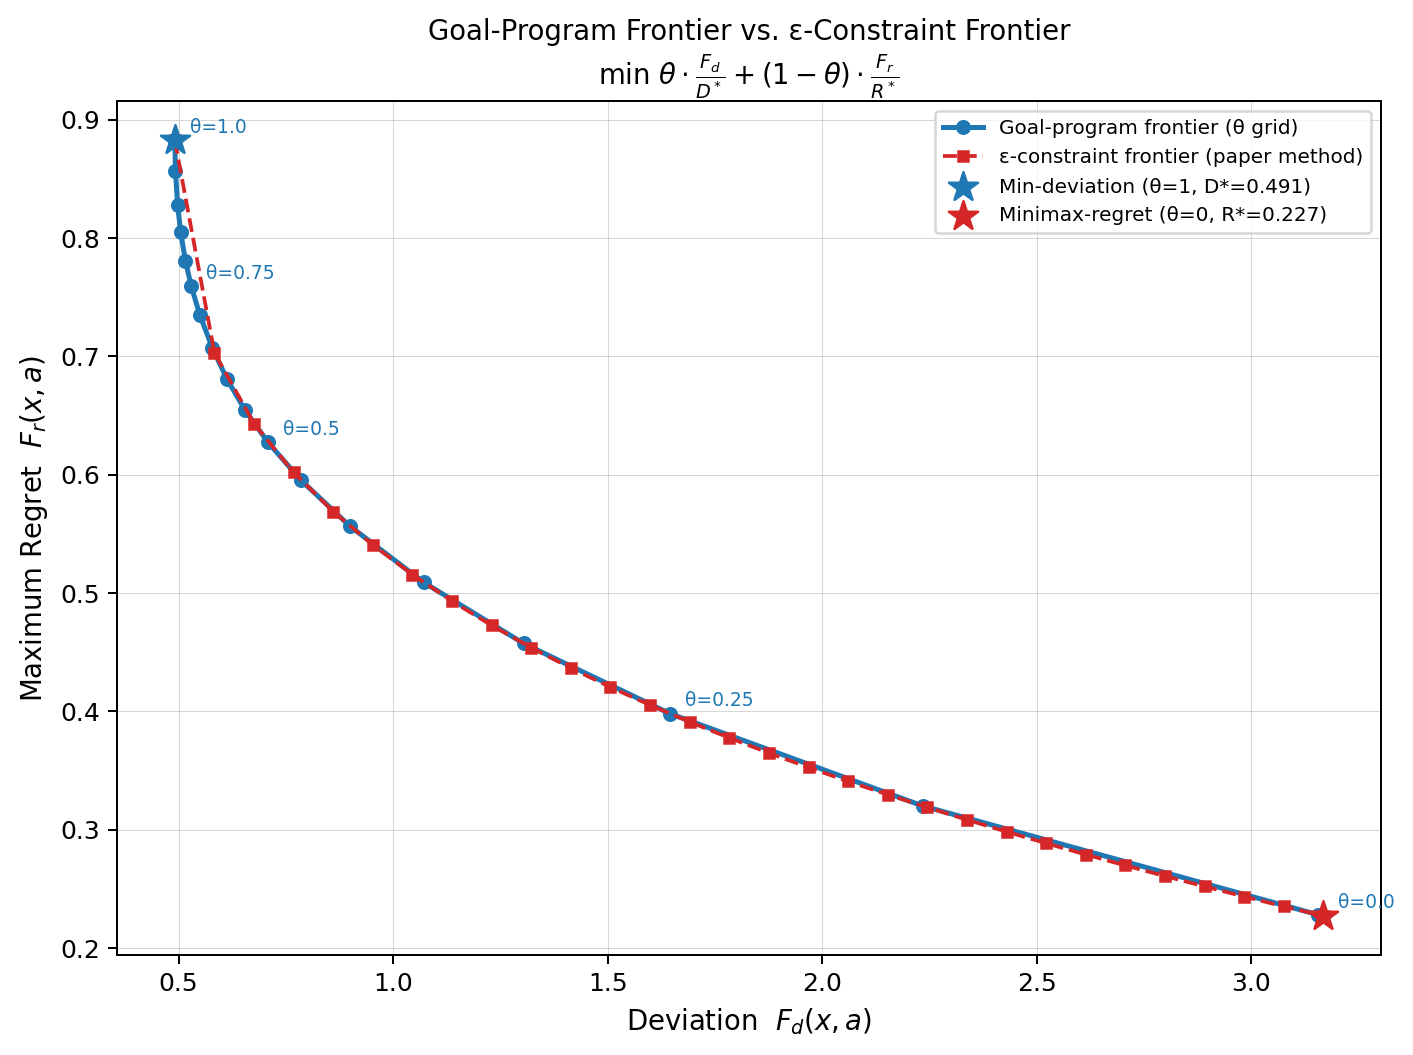

Look at the shape: the frontier is extremely steep at the top-left (θ=0.55 to θ=1.0) and very flat at the bottom-right. This means moving slightly away from pure min-deviation buys enormous reductions in maximum regret at low cost in deviation. The paper identifies min-deviation and minimax-regret as the two poles but never shows how build an allocation model considering what the trade-off is. This chart provides the policymaker the insight that strictly use min-deviation model is a poor deal.

The goal programming framework also lets us compute which subgroups are systematically disadvantaged for every θ, and the θ* that jointly minimizes all three disparity gaps becomes the data-driven recommendation the paper never makes. 

**Why goal programming**

First, normalize both objectives to the same scale — θ=0.5 means placing equal weight on both criteria. 

Second, θ ∈ [0,1] has a direct verbal interpretation a policymaker can engage with: "how much do I care about aggregate alignment with the data versus protecting the worst-off county?" 

Third, it allows the disparity analysis to every point on the frontier through θ, which lets us ask which θ simultaneously minimizes rural/urban, income, and health-factor disparities. That yields a data-driven θ* — an actual recommended allocation — which the paper explicitly does not provide.


The paper's Figure 2 shows that the formula-based allocation and all alpha-fairness allocations (including α=15, the best among them) are strictly inside the frontier — meaning they are dominated. There exist allocations that simultaneously have lower deviation AND lower maximum regret than any of those policies. The goal program, for every single θ ∈ [0,1], produces a point on the frontier. So the entire θ grid dominates the paper's best policy (α=15), and the question of which θ to recommend becomes purely about which frontier point minimizes disparity across subgroups.

**Why we care about equal deviation across subgroups?**

Deviation measures how far a county's allocation is from what its empirical data says it deserves. A high deviation means the county is being allocated either much more or much less than its opioid burden metrics justify. We want to look into the question "does the model systematically misalign allocations for certain groups of counties?"

If rural counties consistently have higher deviation than urban ones, it means the model is worse at matching rural counties' allocations to their actual needs.
High disparity between certain social economic groups means the county's allocation cannot be well-defended by pointing to its empirical metrics.
In the context of the settlement, where all counties need to feel their allocation is data-justified enough to sign, this is a real political vulnerability.

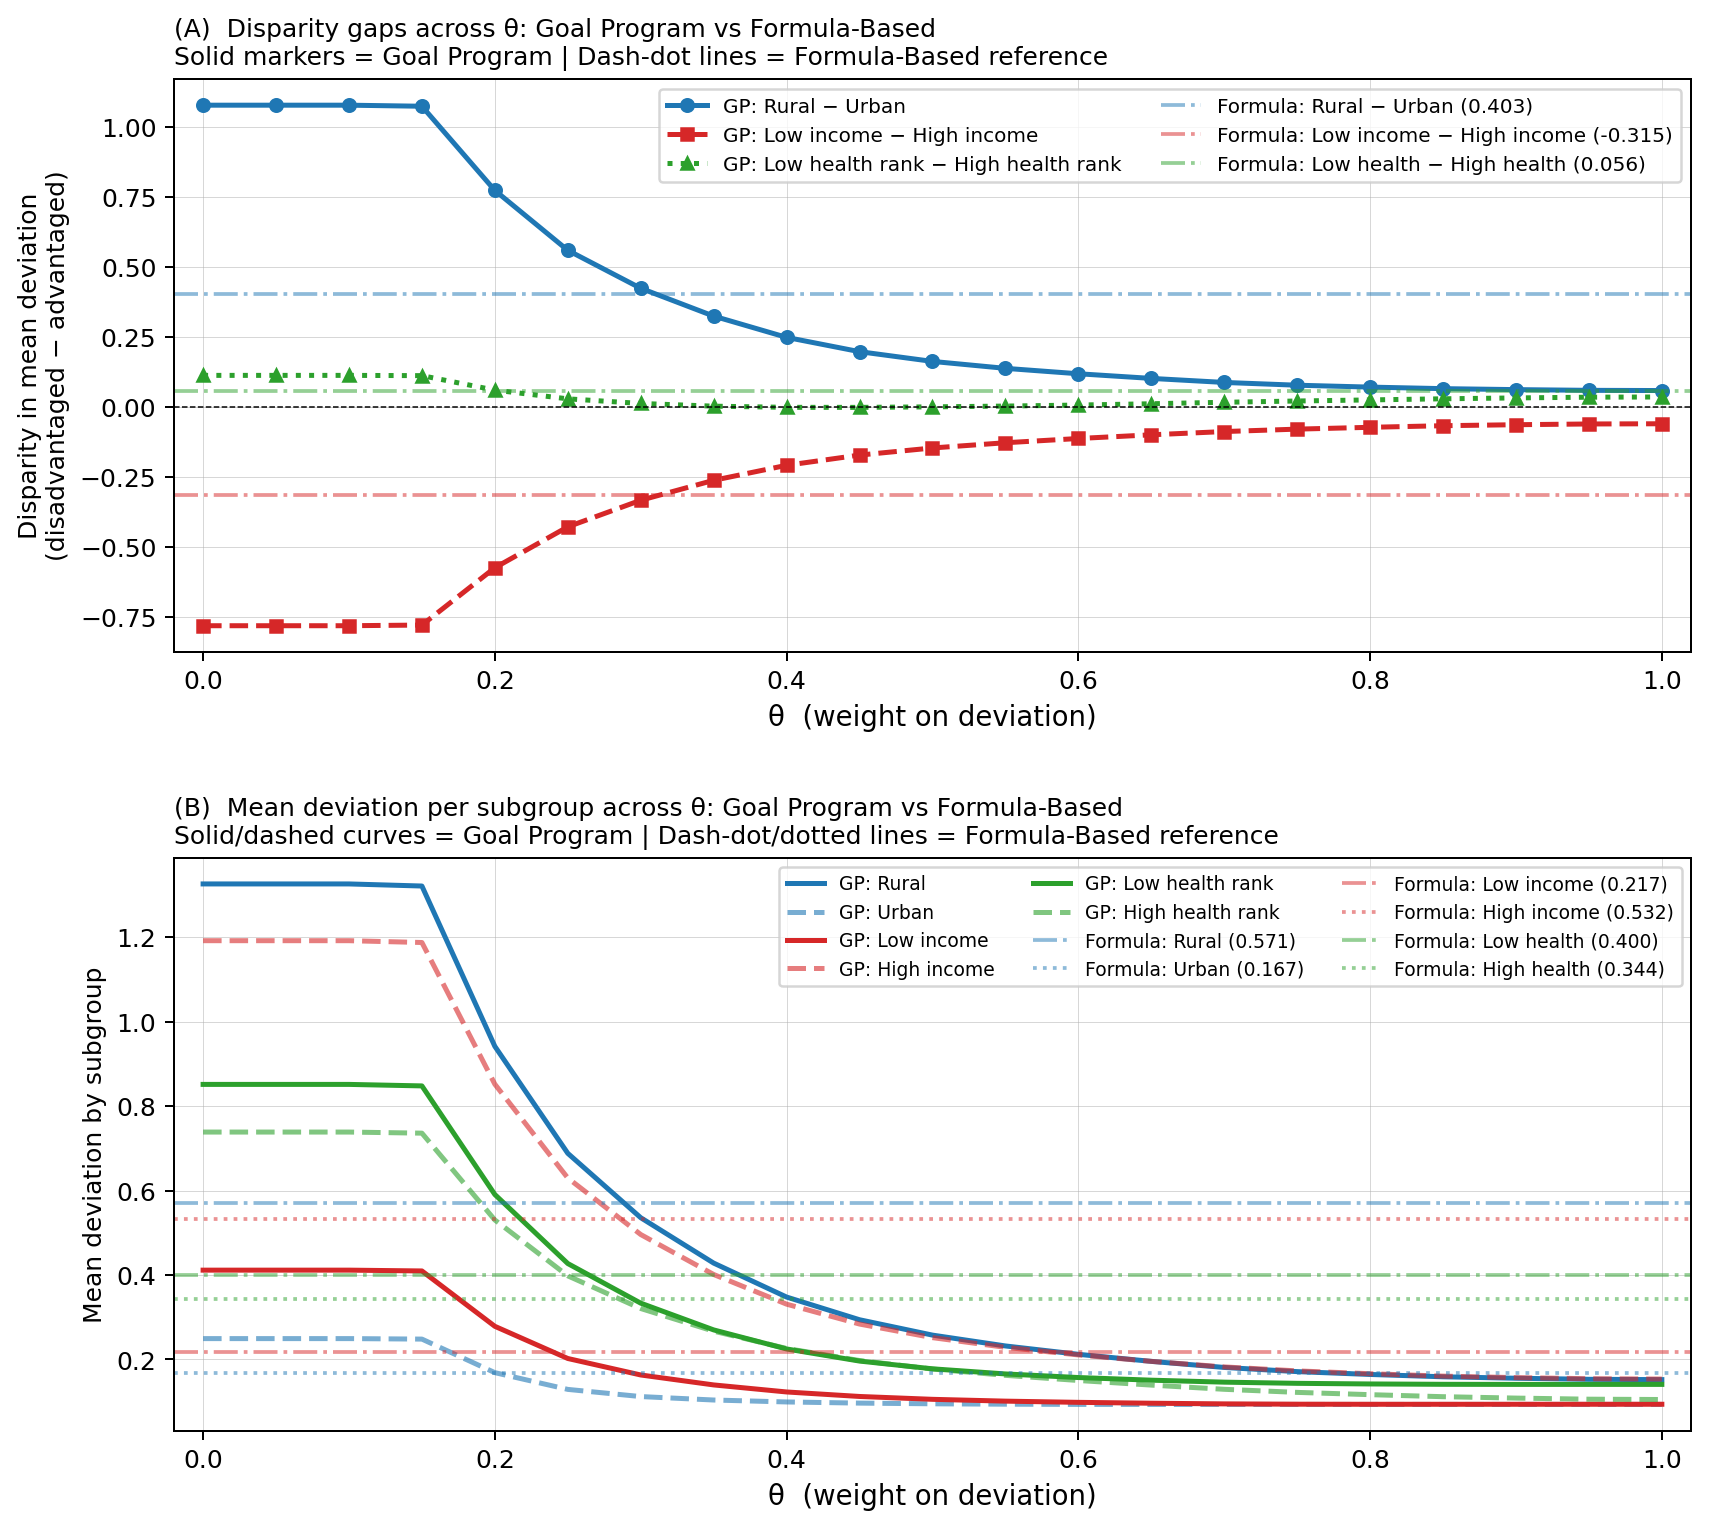


What the chart shows

Panel A has three curves:

The blue Rural minus Urban curve starts very high (~1.07) at θ=0 and falls steadily toward zero at θ=1. This means minimax-regret is terrible for rural counties in terms of deviation fairness — it sacrifices their metric alignment drastically to protect the worst-case regret. As θ increases and the model cares more about deviation, rural counties' alignment improves dramatically. By θ=0.45, the rural-urban gap has already fallen to below 0.25, which is much smaller to the formula's deviation value of 0.403 and gets very close to pure min deviation optimal deviation of around 0.23.

The red Low Income minus High Income curve is the most interesting and unusual finding. It is deeply negative at θ=0 (around -0.75), meaning low-income counties actually have better metric alignment than high-income counties under minimax-regret. The formula sits at -0.315, meaning the formula also inverts this disparity, just less severely than minimax-regret.

The green Low Health minus High Health curve is nearly flat near zero across the entire θ range, staying close to the formula's 0.056 reference. The model is essentially health-neutral on deviation.

The key insight is at θ=0.45,
we find that the disparities across all three groups are much lower compared to formula based model and maximum regret model. No single θ even the pure min deviation model can bring the disparities to zero.


Panel B shows absolute deviation levels rather than gaps. Every single subgroup — rural, urban, low income, high income, low health, high health — has lower mean deviation under the goal program at any θ above about 0.30 compared to the formula. All six curves at θ=0.45 sit below their corresponding formula reference lines. This means tany theta above 0.3 reduce the total amount of unjustifiable allocation across the entire state, improving fairness for everyone simultaneously.


## θ* Selection

### Regret Distribution Animation

According to the paper, all 67 counties within Pennsylvania agreed to the proposed formula-based allocation policy. The agreement was reached through a consensus among the counties, indicating acceptance of the formula-based approach as a practical and transparent solution. The paper described a political constraint that counties need to feel their allocation is "fair" enough to sign. In this case, we define fairness here to also making sure no county gets the allocation that is significantly worse than the maximum value they could have received. Since every county aggred to the formula based policy, we assume that is the highest regret any county faced under the policy that achieved 100% participation. So empirically, counties tolerated regret up to about 59% and still signed. Therefore, any regret value above this threshold will be considered risky.

We also define 23% to be the safe threshold because this is what the minimax regret model could achieve. 

The paper treats maximum regret as a single scalar that moves as we change theta but doesnt give us insights into the distribution of regrets across 67 counties for each theta. In this analysis, we are interested to see how many counties are at risk if we increase theta value to reduce the deviation


Maximum regret ≤ formula-based (staying within the established political tolerance)
Lower deviation than formula-based (better alignment with empirical need)
All 67 counties in the "politically safe" zone

The GIF reveals the distribution of regret, which shows something qualitatively different: at θ=0.5, 12 counties sit in the risky zone (above 59.5%), meaning the political risk isn't just about one outlier county, we're looking at a group of dissatisfied counties that could collectively refuse. That's a fundamentally different threat model than what the minimax formulation captures. The paper proposed the frontier curve but never consider the political constraint of picking min deviation model could potentially leads to huge disagreement from the 11 worst off counties. 

At minimax-regret, every county has almost identical regret (~22.7%), which the paper notes. But the GIF makes viscerally clear that this "equality of misery" comes at the cost of everyone is uniformly under-served relative to their best metric. The paper frames minimax-regret positively as eliminating disparity, but the GIF reframes it as close to zero disparity in regret is achieved by compressing everyone to the same poor outcome, not by improving outcomes. That's a subtle but important critique.

The transition dynamics between θ=0.10 and θ=0.20 are nonlinear
Looking at the table output, Fd drops from 3.168 to 2.234 (a 30% improvement) just moving from θ=0.10 to θ=0.20, while Fr only worsens from 0.227 to 0.320. 

In [12]:
"""
Regret Distribution Animation & Static Comparison
===================================================
Generates:
  regret_distribution.gif        — animated histogram across all theta values
  regret_distribution_3panel.png — static comparison at theta=0, theta*, theta=1

Requirements:
    pip install gurobipy matplotlib numpy Pillow

Place in same directory as Master DataFrame.csv.
The solve_goal() function and data loading above this script must be present
in the same notebook/session, OR this file can be run standalone as written.
"""

import csv
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image as PILImage
import gurobipy as gp
from gurobipy import GRB


THETA_STAR   = 0.65
TOTAL        = 749_000_000
STATE_MEDIAN = 64_758

THETA_GRID = [round(t, 2) for t in np.linspace(0, 1, 21)]

# Regret threshold definitions
# Anchored empirically: the formula-based allocation achieved 100% county
# participation with a maximum regret of ~0.595, establishing an empirical
# upper bound on what counties were willing to tolerate.
# T_SAFE = R* (minimax-regret optimum) = counties receiving their best possible outcome
# T_WARN = observed formula max regret = counties still signed at this level
T_SAFE = 0.23   # below this = safe (green)   — near minimax-regret optimum
T_WARN = 0.595   # above this = at-risk (red)  — approaching formula max regret

# Plot colors
C_SAFE = "#2ecc71"
C_WARN = "#f39c12"
C_RISK = "#e74c3c"
C_FORM = "#95a5a6"

METRIC_COLS = {
    "overdose":        "all drug overdose share",
    "hospitalization": "hospitalization share",
    "naloxone":        "nalxone share",
    "mme":             "MME adjusted share",
}

# ─────────────────────────────────────────────────────────────────────────────
# 1.  Load data
# ─────────────────────────────────────────────────────────────────────────────
counties       = []
shares         = {}
a_max          = {} 
a_min          = {}
meta_rural     = {}
meta_income_hi = {}

with open("Master DataFrame.csv", newline="", encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)
    reader.fieldnames = [h.strip() for h in reader.fieldnames]
    for row in reader:
        row = {k.strip(): v.strip() for k, v in row.items()}
        c = row["County"]
        counties.append(c)
        shares[c]         = {m: float(row[col]) for m, col in METRIC_COLS.items()}
        a_max[c]          = max(shares[c].values())
        a_min[c]          = min(shares[c].values())
        meta_rural[c]     = int(row["rural_urban_binary"])
        meta_income_hi[c] = int(row["income_rank_binary"])

METRICS = list(METRIC_COLS.keys())
N       = len(counties)

# ─────────────────────────────────────────────────────────────────────────────
# 2.  Helper functions
# ─────────────────────────────────────────────────────────────────────────────
def compute_regrets(alloc):
    return np.array([1 - alloc[c] / a_max[c] for c in counties])

def compute_Fd(alloc):
    return sum(
        (1 - alloc[c] / shares[c][m]) ** 2
        for c in counties for m in METRICS if shares[c][m] > 0
    ) / N

def bar_color(midpoint):
    if midpoint <= T_SAFE: return C_SAFE
    if midpoint <= T_WARN: return C_WARN
    return C_RISK

# ─────────────────────────────────────────────────────────────────────────────
# 3.  Gurobi solver
# ─────────────────────────────────────────────────────────────────────────────
def solve_goal(theta):
    """
    min  theta * Fd(x,a)/D*  +  (1-theta) * Fr(x,a)/R*
    Convex for all theta in [0,1]:
      Fd is quadratic (convex), Fr linearised via auxiliary r (linear).
    """
    m = gp.Model(f"goal_{theta:.2f}")
    m.Params.OutputFlag = 0
    x = {c: m.addVar(lb=a_min[c], ub=a_max[c]) for c in counties}
    r = m.addVar(lb=0.0)
    m.addConstr(gp.quicksum(x[c] for c in counties) == 1)
    for c in counties:
        m.addConstr(r >= 1 - x[c] / a_max[c])
    dev_terms = [
        (1 - x[c] / shares[c][met]) ** 2
        for c in counties for met in METRICS if shares[c][met] > 0
    ]
    Fd_expr = (1.0 / N) * gp.quicksum(dev_terms)
    m.setObjective(
        theta * (Fd_expr / D_STAR) + (1.0 - theta) * (r / R_STAR),
        GRB.MINIMIZE
    )
    m.optimize()
    if m.Status not in (GRB.OPTIMAL, GRB.SUBOPTIMAL):
        print(f"  WARNING: theta={theta:.2f} status={m.Status}")
        return None
    return {c: x[c].X for c in counties}

# ─────────────────────────────────────────────────────────────────────────────
# 4.  Solve all theta values
# ─────────────────────────────────────────────────────────────────────────────
formula_alloc = {
    c: 0.4 * shares[c]["overdose"]
     + 0.2 * shares[c]["hospitalization"]
     + 0.2 * shares[c]["naloxone"]
     + 0.2 * shares[c]["mme"]
    for c in counties
}

print("Solving goal program across theta grid...")
all_allocs = {}
for t in THETA_GRID:
    print(f"  theta={t:.2f}...", end=" ", flush=True)
    alloc = solve_goal(t)
    if alloc:
        all_allocs[t] = alloc
        print("done")
    else:
        print("failed")

# Precompute regret arrays — done ONCE outside the frame loop
all_regrets     = {t: compute_regrets(all_allocs[t])
                   for t in THETA_GRID if t in all_allocs}
formula_regrets = compute_regrets(formula_alloc)

# Fixed histogram of formula regrets — computed once, used in static figure only
BINS        = np.linspace(0, 1.0, 26)
f_counts, _ = np.histogram(formula_regrets, bins=BINS)

# Subgroup indices
rural_idx  = [i for i, c in enumerate(counties) if meta_rural[c]     == 1]
urban_idx  = [i for i, c in enumerate(counties) if meta_rural[c]     == 0]
lo_inc_idx = [i for i, c in enumerate(counties) if meta_income_hi[c] == 0]
hi_inc_idx = [i for i, c in enumerate(counties) if meta_income_hi[c] == 1]

rng = np.random.RandomState(42)   # fixed seed for consistent jitter across frames

# ─────────────────────────────────────────────────────────────────────────────
# 5.  Build GIF frames
# NOTE: Formula baseline deliberately excluded from GIF frames.
#       It is a fixed line that does not change with theta, adding visual
#       clutter without contributing information to the animation.
#       It appears only in the static 3-panel figure for direct comparison.
# ─────────────────────────────────────────────────────────────────────────────
print("\nGenerating animation frames...")
frames    = []
durations = []

for t in THETA_GRID:
    if t not in all_regrets:
        continue

    r         = all_regrets[t]
    counts, _ = np.histogram(r, bins=BINS)

    # ── Figure layout ─────────────────────────────────────────────────────
    fig = plt.figure(figsize=(13, 7), facecolor="white")
    gs  = gridspec.GridSpec(
        2, 3, figure=fig,
        hspace=0.50, wspace=0.38,
        left=0.07, right=0.97, top=0.88, bottom=0.10
    )
    ax_hist  = fig.add_subplot(gs[0, :2])
    ax_strip = fig.add_subplot(gs[1, :2])
    ax_stats = fig.add_subplot(gs[:, 2])

    # ── Top: histogram ────────────────────────────────────────────────────
    for left, right, cnt in zip(BINS[:-1], BINS[1:], counts):
        ax_hist.bar(left, cnt, width=(right - left) * 0.9,
                    color=bar_color((left + right) / 2),
                    alpha=0.85, align="edge")

    ax_hist.axvline(T_SAFE, color=C_WARN, lw=1.5, ls=":", alpha=0.9)
    ax_hist.axvline(T_WARN, color=C_RISK, lw=1.5, ls=":", alpha=0.9)
    ax_hist.text(T_SAFE + 0.01, counts.max() * 0.92,
                 f"{int(T_SAFE*100)}%", color=C_WARN, fontsize=8, fontweight="bold")
    ax_hist.text(T_WARN + 0.01, counts.max() * 0.82,
                 f"{int(T_WARN*100)}%", color=C_RISK, fontsize=8, fontweight="bold")

    ax_hist.axvline(r.mean(), color="#2c3e50", lw=2)
    ax_hist.axvline(r.max(),  color="#8e44ad", lw=2, ls="--")

    ax_hist.set_xlim(0, 1.0)
    ax_hist.set_ylim(0, counts.max() * 1.30)
    ax_hist.set_xlabel(
        "Regret  (1 - allocation / best justifiable claim)", fontsize=9)
    ax_hist.set_ylabel("Number of Counties", fontsize=9)
    ax_hist.set_title(
        f"Regret Distribution - 67 PA Counties  |  theta = {t:.2f}",
        fontsize=11, fontweight="bold")

    legend_patches = [
        plt.Rectangle((0,0),1,1, color=C_SAFE,
                       label=f"Safe (<={int(T_SAFE*100)}%): {np.sum(r<=T_SAFE)} counties"),
        plt.Rectangle((0,0),1,1, color=C_WARN,
                       label=f"Warning ({int(T_SAFE*100)}-{int(T_WARN*100)}%): "
                             f"{np.sum((r>T_SAFE)&(r<=T_WARN))} counties"),
        plt.Rectangle((0,0),1,1, color=C_RISK,
                       label=f"At-Risk (>{int(T_WARN*100)}%): {np.sum(r>T_WARN)} counties"),
        plt.Line2D([0],[0], color="#2c3e50", lw=2,
                   label=f"Mean = {r.mean():.3f}"),
        plt.Line2D([0],[0], color="#8e44ad", lw=2, ls="--",
                   label=f"Max  = {r.max():.3f}"),
    ]
    ax_hist.legend(handles=legend_patches, fontsize=7.5,
                   loc="upper right", framealpha=0.9)

    # ── Bottom: strip / dot plot by subgroup ──────────────────────────────
    subgroups = [
        ("Rural",      rural_idx,  2),
        ("Urban",      urban_idx,  1),
        ("Low Income", lo_inc_idx, 0),
        ("Hi Income",  hi_inc_idx,-1),
    ]
    for grp_name, idx, y_pos in subgroups:
        gr     = r[np.array(idx)]
        jitter = rng.uniform(-0.18, 0.18, len(gr))
        ax_strip.scatter(
            gr, np.full_like(gr, y_pos) + jitter,
            c=[bar_color(rv) for rv in gr],
            s=38, alpha=0.80, edgecolors="white", lw=0.5, zorder=3)
        ax_strip.plot(gr.mean(), y_pos, marker="|",
                      ms=18, mew=3, color="#2c3e50", zorder=5)
        ax_strip.text(-0.02, y_pos, grp_name,
                      ha="right", va="center", fontsize=8.5)

    ax_strip.axvline(T_SAFE, color=C_WARN, lw=1.5, ls=":", alpha=0.8)
    ax_strip.axvline(T_WARN, color=C_RISK, lw=1.5, ls=":", alpha=0.8)
    ax_strip.set_xlim(-0.05, 1.0)
    ax_strip.set_ylim(-1.6, 2.6)
    ax_strip.set_yticks([])
    ax_strip.set_xlabel(
        "Regret per county  (each dot = 1 county,  | = group mean)", fontsize=8.5)
    ax_strip.set_title("Regret by Subgroup", fontsize=9, loc="left")
    ax_strip.grid(axis="x", alpha=0.3)

    # ── Right: stats panel ────────────────────────────────────────────────
    ax_stats.axis("off")

    # theta progress bar
    ax_stats.add_patch(plt.Rectangle(
        (0.05, 0.94), 0.90, 0.035,
        facecolor="#ecf0f1", edgecolor="#bdc3c7",
        transform=ax_stats.transAxes, clip_on=False))
    ax_stats.add_patch(plt.Rectangle(
        (0.05, 0.94), 0.90 * t, 0.035,
        facecolor="#3498db",
        transform=ax_stats.transAxes, clip_on=False))
    ax_stats.text(
        0.50, 0.915, f"theta = {t:.2f}",
        ha="center", va="top", fontsize=15, fontweight="bold",
        color="#2c3e50", transform=ax_stats.transAxes)

    pct_above_safe = np.mean(r > T_SAFE) * 100
    stats_items = [
        ("Max Regret",              f"{r.max():.4f}",       "#8e44ad"),
        ("Mean Regret",             f"{r.mean():.4f}",       "#2c3e50"),
        ("Median Regret",           f"{np.median(r):.4f}",   "#2c3e50"),
        ("Std Dev",                 f"{r.std():.4f}",         "#7f8c8d"),
        (f"% Above {int(T_SAFE*100)}%",  f"{pct_above_safe:.1f}%",
         C_RISK if pct_above_safe > 30 else C_WARN if pct_above_safe > 10 else C_SAFE),
        ("Fd",                      f"{compute_Fd(all_allocs[t]):.4f}", "#16a085"),
    ]
    y_text = 0.83
    for label, value, color in stats_items:
        ax_stats.text(0.05, y_text, label, fontsize=9, color="#7f8c8d",
                     transform=ax_stats.transAxes)
        ax_stats.text(0.95, y_text, value, fontsize=10, fontweight="bold",
                     color=color, ha="right", transform=ax_stats.transAxes)
        y_text -= 0.095

    ax_stats.text(0.50, 0.20, "-- vs Formula --",
                 ha="center", fontsize=8, color="#95a5a6",
                 transform=ax_stats.transAxes)
    comp_items = [
        ("Delta Max Regret",
         r.max() - formula_regrets.max()),
        ("Delta Mean Regret",
         r.mean() - formula_regrets.mean()),
        (f"Delta % > {int(T_SAFE*100)}%",
         (np.mean(r > T_SAFE) - np.mean(formula_regrets > T_SAFE)) * 100),
    ]
    y_text = 0.15
    for label, delta in comp_items:
        color = "#27ae60" if delta < 0 else "#e74c3c"
        sign  = "+" if delta >= 0 else ""
        unit  = "%" if "%" in label else ""
        ax_stats.text(0.05, y_text, label, fontsize=8, color="#7f8c8d",
                     transform=ax_stats.transAxes)
        ax_stats.text(0.95, y_text, f"{sign}{delta:.3f}{unit}",
                     fontsize=9, fontweight="bold", color=color,
                     ha="right", transform=ax_stats.transAxes)
        y_text -= 0.085

    fig.text(0.40, 0.005,
             f"Safe (<={int(T_SAFE*100)}%)   "
             f"Warning ({int(T_SAFE*100)}-{int(T_WARN*100)}%)   "
             f"At-Risk (>{int(T_WARN*100)}%)",
             ha="center", fontsize=8, color="#555")

    # ── Capture frame ─────────────────────────────────────────────────────
    fig.canvas.draw()
    buf = fig.canvas.buffer_rgba()
    arr = np.frombuffer(buf, dtype=np.uint8).reshape(
        fig.canvas.get_width_height()[::-1] + (4,))
    frames.append(PILImage.fromarray(arr[:, :, :3]))
    plt.close(fig)

    if abs(t - THETA_STAR) < 0.01:
        durations.append(1500)
    elif t in (0.0, 1.0):
        durations.append(1000)
    else:
        durations.append(400)

    print(f"  theta={t:.2f} done")

# ─────────────────────────────────────────────────────────────────────────────
# 6.  Save GIF
# ─────────────────────────────────────────────────────────────────────────────
print(f"\nSaving GIF ({len(frames)} frames)...")
frames[0].save(
    "regret_distribution.gif",
    save_all=True,
    append_images=frames[1:],
    duration=durations,
    loop=0,
)
print("Saved: regret_distribution.gif")

# ─────────────────────────────────────────────────────────────────────────────
# 7.  Static 3-panel comparison (formula baseline shown here only)
# ─────────────────────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5), sharey=True, facecolor="white")
key_thetas  = [0.0, 0.4, 0.5]
titles      = [
    "theta = 0.00  (Minimax-Regret)",
    "theta = 0.4",
    "theta = 0.5",
]

for ax2, t, title in zip(axes2, key_thetas, titles):
    r          = all_regrets[t]
    counts2, _ = np.histogram(r, bins=BINS)

    for left, right, cnt in zip(BINS[:-1], BINS[1:], counts2):
        ax2.bar(left, cnt, width=(right - left) * 0.9,
                color=bar_color((left + right) / 2), alpha=0.85, align="edge")

    ax2.step(BINS[:-1], f_counts, where="post",
             color=C_FORM, lw=2, ls="--", alpha=0.8, label="Formula")

    ax2.axvline(T_SAFE, color=C_WARN, lw=1.5, ls=":")
    ax2.axvline(T_WARN, color=C_RISK, lw=1.5, ls=":")
    ax2.axvline(r.mean(), color="#2c3e50", lw=2,
                label=f"Mean={r.mean():.3f}")
    ax2.axvline(r.max(),  color="#8e44ad", lw=2, ls="--",
                label=f"Max={r.max():.3f}")

    safe_n = np.sum(r <= T_SAFE)
    warn_n = np.sum((r > T_SAFE) & (r <= T_WARN))
    risk_n = np.sum(r > T_WARN)
    ax2.text(0.97, 0.95,
             f"Safe:{safe_n}  Warn:{warn_n}  Risk:{risk_n}",
             ha="right", va="top", transform=ax2.transAxes, fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    ax2.set_xlim(0, 1.0)
    ax2.set_xlabel("Regret", fontsize=9)
    ax2.set_title(title, fontsize=10, fontweight="bold",
                  color= "#2c3e50")
    ax2.legend(fontsize=8)
    ax2.grid(axis="y", alpha=0.3)

axes2[0].set_ylabel("Number of Counties", fontsize=9)
plt.suptitle(
    "Regret Distribution: Three Key Policies Compared\n"
    f"Green=Safe(<={int(T_SAFE*100)}%)  "
    f"Orange=Warning({int(T_SAFE*100)}-{int(T_WARN*100)}%)  "
    f"Red=At-Risk(>{int(T_WARN*100)}%)  "
    "Grey dashes=Formula",
    fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("regret_distribution_3panel.png", dpi=160, bbox_inches="tight")
plt.close()

Solving goal program across theta grid...
  theta=0.00... done
  theta=0.05... done
  theta=0.10... done
  theta=0.15... done
  theta=0.20... 

done
  theta=0.25... done
  theta=0.30... done
  theta=0.35... done
  theta=0.40... done
  theta=0.45... done
  theta=0.50... done
  theta=0.55... done
  theta=0.60... done
  theta=0.65... done
  theta=0.70... done
  theta=0.75... done
  theta=0.80... done
  theta=0.85... done
  theta=0.90... done
  theta=0.95... done
  theta=1.00... done

Generating animation frames...
  theta=0.00 done
  theta=0.05 done
  theta=0.10 done
  theta=0.15 done
  theta=0.20 done
  theta=0.25 done
  theta=0.30 done
  theta=0.35 done
  theta=0.40 done
  theta=0.45 done
  theta=0.50 done
  theta=0.55 done
  theta=0.60 done
  theta=0.65 done
  theta=0.70 done
  theta=0.75 done
  theta=0.80 done
  theta=0.85 done
  theta=0.90 done
  theta=0.95 done
  theta=1.00 done

Saving GIF (21 frames)...
Saved: regret_distribution.gif


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# County-Level Regret Tracking Across Theta
# Identifies which counties are at-risk, whether they are stable,
# and characterizes their subgroup profile
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

T_SAFE = 0.23   # formula-based max regret threshold (safe zone)
T_WARN = 0.595   # at-risk threshold

# ── 1. Compute per-county regret at every theta ───────────────────────────────
# Use the full theta grid already solved
TRACKING_THETAS = sorted([t for t in all_allocs.keys()])

regret_records = []
for theta in TRACKING_THETAS:
    alloc = all_allocs[theta]
    for c in counties:
        regret_val = 1 - alloc[c] / a_max[c]
        if regret_val <= T_SAFE:
            zone = "Safe"
        elif regret_val <= T_WARN:
            zone = "Warning"
        else:
            zone = "At-Risk"
        regret_records.append({
            "theta"      : theta,
            "County"     : c,
            "Regret"     : regret_val,
            "Zone"       : zone,
            "Rural/Urban": "Rural"      if meta[c]["rural"]  == 1 else "Urban",
            "Income"     : "Low Income" if meta[c]["income"] == 0 else "High Income",
            "Health"     : "Low Health" if meta[c]["health"] == 1 else "High Health",
        })

df_track = pd.DataFrame(regret_records)

# ── 2. Pivot to wide format: county × theta ───────────────────────────────────
df_regret_wide = df_track.pivot(index="County", columns="theta", values="Regret")
df_zone_wide   = df_track.pivot(index="County", columns="theta", values="Zone")

# ── 3. Identify counties that ever enter At-Risk zone ────────────────────────
ever_at_risk = df_zone_wide[
    (df_zone_wide == "At-Risk").any(axis=1)
].index.tolist()

always_at_risk = df_zone_wide[
    (df_zone_wide == "At-Risk").all(axis=1)
].index.tolist()

never_at_risk = df_zone_wide[
    (df_zone_wide != "At-Risk").all(axis=1)
].index.tolist()

# Counties that transition INTO at-risk at some theta
transitioning = [c for c in ever_at_risk if c not in always_at_risk]

print("=" * 70)
print("COUNTY RISK ZONE STABILITY ANALYSIS")
print("=" * 70)
print(f"\nTotal counties: {len(counties)}")
print(f"Never at-risk  (stable safe/warning): {len(never_at_risk)}")
print(f"Always at-risk (at-risk across all θ): {len(always_at_risk)}")
print(f"Transitioning  (enter at-risk at some θ): {len(transitioning)}")

print(f"\n── Always At-Risk Counties ({'none' if not always_at_risk else ''})──")
for c in always_at_risk:
    sub = df_track[df_track.County == c].iloc[0]
    regrets = df_regret_wide.loc[c]
    print(f"  {c:<20} {sub['Rural/Urban']:<8} {sub['Income']:<13} {sub['Health']:<12}"
          f"  regret range: [{regrets.min():.3f}, {regrets.max():.3f}]")

print(f"\n── Transitioning Counties (enter at-risk as θ increases) ──")
for c in sorted(transitioning):
    sub      = df_track[df_track.County == c].iloc[0]
    # Find first theta where county becomes at-risk
    at_risk_thetas = [t for t in TRACKING_THETAS
                      if df_zone_wide.loc[c, t] == "At-Risk"]
    entry_theta = min(at_risk_thetas) if at_risk_thetas else None
    regrets = df_regret_wide.loc[c]
    print(f"  {c:<20} {sub['Rural/Urban']:<8} {sub['Income']:<13} {sub['Health']:<12}"
          f"  enters at-risk at θ={entry_theta:.2f}"
          f"  regret @ θ=0.4: {df_regret_wide.loc[c, 0.45]:.3f}"
          f"  regret @ θ=1.00: {df_regret_wide.loc[c, 1.00]:.3f}")

# ── 4. Zone transition matrix ─────────────────────────────────────────────────
# For each county, show their zone at key theta values
KEY_THETAS = [t for t in TRACKING_THETAS if t in [0.0, 0.25, 0.35, 0.45, 0.55, 0.65, 0.80, 1.00]]

print(f"\n── Zone at Key Theta Values (At-Risk counties only) ──")
header_thetas = "  ".join([f"θ={t:.2f}" for t in KEY_THETAS])
print(f"  {'County':<20} {header_thetas}")
print("-" * 90)

for c in sorted(ever_at_risk):
    zones = "  ".join([
        f"{'AR':^6}" if df_zone_wide.loc[c, t] == "At-Risk"
        else f"{'W':^6}"  if df_zone_wide.loc[c, t] == "Warning"
        else f"{'S':^6}"
        for t in KEY_THETAS
    ])
    sub = df_track[df_track.County == c].iloc[0]
    print(f"  {c:<20} {zones}  | {sub['Rural/Urban']:<8} {sub['Income']:<13} {sub['Health']}")

# ── 5. Subgroup profile of at-risk counties ───────────────────────────────────
print(f"\n── Subgroup Profile: Ever-At-Risk vs Never-At-Risk ──")
for group_name, group_counties in [("Ever At-Risk", ever_at_risk),
                                    ("Never At-Risk", never_at_risk)]:
    sub_df = df_track[df_track.County.isin(group_counties)].drop_duplicates("County")
    print(f"\n  {group_name} (n={len(group_counties)}):")
    for col in ["Rural/Urban", "Income", "Health"]:
        counts = sub_df[col].value_counts()
        for label, cnt in counts.items():
            pct = cnt / len(group_counties) * 100
            print(f"    {col}: {label:<15} {cnt:>2} ({pct:.0f}%)")

# ── 6. Figure A: Regret heatmap — county × theta ─────────────────────────────
fig, ax = plt.subplots(figsize=(14, 16))

# Sort counties by regret at θ=0.45 for readability
sort_order = df_regret_wide[0.45].sort_values(ascending=False).index
heat_data  = df_regret_wide.loc[sort_order, TRACKING_THETAS].values

# Custom colormap: green → orange → red
cmap = LinearSegmentedColormap.from_list(
    "regret", ["#2ecc71", "#f39c12", "#e74c3c"], N=256)

im = ax.imshow(heat_data, aspect="auto", cmap=cmap, vmin=0, vmax=1,
               interpolation="nearest")

ax.set_xticks(range(len(TRACKING_THETAS)))
ax.set_xticklabels([f"{t:.2f}" for t in TRACKING_THETAS], fontsize=8, rotation=45)
ax.set_yticks(range(len(sort_order)))
ax.set_yticklabels(sort_order, fontsize=7)
ax.set_xlabel("θ", fontsize=11)
ax.set_ylabel("County (sorted by regret at θ=0.45)", fontsize=10)
ax.set_title("County Regret Heatmap Across θ\n"
             "Green=Safe(≤23%)  Orange=Warning(23–59%)  Red=At-Risk(>59%)",
             fontsize=11, fontweight="bold")

# Threshold lines on colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
cbar.set_label("Regret Value", fontsize=9)
cbar.ax.axhline(T_SAFE, color="black", lw=1.5, ls="--")
cbar.ax.axhline(T_WARN, color="black", lw=1.5, ls="--")
cbar.ax.text(1.05, T_SAFE, "23%", va="center", fontsize=7, transform=cbar.ax.transData)
cbar.ax.text(1.05, T_WARN, "59%", va="center", fontsize=7, transform=cbar.ax.transData)

# Vertical line at θ=0.4
theta_045_idx = TRACKING_THETAS.index(0.4) if 0.4 in TRACKING_THETAS else None
if theta_045_idx is not None:
    ax.axvline(theta_045_idx, color="white", lw=2, ls="--", alpha=0.8,
               label="θ=0.4")
    ax.legend(fontsize=9, loc="upper left")

plt.tight_layout()
plt.savefig("figure_regret_heatmap.png", dpi=180, bbox_inches="tight")
plt.close()
print("\nSaved: figure_regret_heatmap.png")

# ── 7. Figure B: Regret trajectories for at-risk counties only ───────────────
fig, ax = plt.subplots(figsize=(12, 6))

color_by_rural = {"Rural": "#d62728", "Urban": "#1f77b4"}

for c in sorted(ever_at_risk):
    sub      = df_track[df_track.County == c].iloc[0]
    color    = color_by_rural[sub["Rural/Urban"]]
    regrets  = [df_regret_wide.loc[c, t] for t in TRACKING_THETAS]
    ax.plot(TRACKING_THETAS, regrets, color=color, lw=1.5, alpha=0.7)
    # Label at θ=1.0
    ax.text(TRACKING_THETAS[-1] + 0.01, regrets[-1],
            c, fontsize=6.5, va="center", color=color)

ax.axhline(T_SAFE, color="#f39c12", lw=1.5, ls="--", label=f"Safe threshold ({int(T_SAFE*100)}%)")
ax.axhline(T_WARN, color="#e74c3c", lw=1.5, ls="--", label=f"At-risk threshold ({int(T_WARN*100)}%)")
ax.axvline(0.4,   color="#8e44ad", lw=1.5, ls="--", label="θ=0.4")

rural_patch = mpatches.Patch(color="#d62728", label="Rural county",  alpha=0.7)
urban_patch = mpatches.Patch(color="#1f77b4", label="Urban county",  alpha=0.7)
ax.legend(handles=[rural_patch, urban_patch] +
          ax.get_legend_handles_labels()[0], fontsize=8, loc="upper left")

ax.set_xlabel("θ  (weight on deviation)", fontsize=11)
ax.set_ylabel("Regret  (1 − allocation / best justifiable claim)", fontsize=10)
ax.set_title("Regret Trajectories of Counties That Ever Enter At-Risk Zone\n"
             "Colored by Rural/Urban status", fontsize=11, fontweight="bold")
ax.set_xlim(-0.02, 1.08)
ax.set_ylim(0, 1.0)
ax.grid(True, linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig("figure_atrisk_trajectories.png", dpi=180, bbox_inches="tight")
plt.close()
print("Saved: figure_atrisk_trajectories.png")

# ── 8. What to do depending on stability finding ─────────────────────────────
print("\n" + "=" * 70)
print("=" * 70)

at_risk_at_045 = [c for c in counties
                  if 0.45 in TRACKING_THETAS
                  and df_zone_wide.loc[c, 0.45] == "At-Risk"]

at_risk_at_1 = [c for c in counties
                  if 1 in TRACKING_THETAS
                  and df_zone_wide.loc[c, 1] == "At-Risk"]

new_at_risk_045_to_1 = set(at_risk_at_1) - set(at_risk_at_045)
left_at_risk_045_to_1 = set(at_risk_at_045) - set(at_risk_at_1)

print(f"\nAt-risk at θ=0.45: {len(at_risk_at_045)} counties → {at_risk_at_045}")
print(f"At-risk at θ=1: {len(at_risk_at_1)} counties → {at_risk_at_1}")
print(f"New entrants  (045→1): {len(new_at_risk_045_to_1)} → {new_at_risk_045_to_1}")
print(f"Counties that left (045→065): {len(left_at_risk_045_to_1)} → {left_at_risk_045_to_1}")

COUNTY RISK ZONE STABILITY ANALYSIS

Total counties: 67
Never at-risk  (stable safe/warning): 56
Always at-risk (at-risk across all θ): 0
Transitioning  (enter at-risk at some θ): 11

── Always At-Risk Counties (none)──

── Transitioning Counties (enter at-risk as θ increases) ──
  Cambria              Urban    High Income   Low Health    enters at-risk at θ=0.45  regret @ θ=0.4: 0.595  regret @ θ=1.00: 0.706
  Cameron              Rural    High Income   Low Health    enters at-risk at θ=0.45  regret @ θ=0.4: 0.595  regret @ θ=1.00: 0.681
  Clearfield           Rural    High Income   Low Health    enters at-risk at θ=0.45  regret @ θ=0.4: 0.595  regret @ θ=1.00: 0.655
  Elk                  Rural    High Income   High Health   enters at-risk at θ=0.45  regret @ θ=0.4: 0.595  regret @ θ=1.00: 0.644
  Forest               Rural    High Income   Low Health    enters at-risk at θ=0.45  regret @ θ=0.4: 0.595  regret @ θ=1.00: 0.618
  Fulton               Rural    Low Income    Low Health   

The 11 at-risk counties are structurally determined — they enter at-risk at θ=0.45 and stay there regardless of how high θ goes. This means their vulnerability is not caused by θ choice, it is a property of their metric profiles. Specifically, look at the subgroup data: 10 of 11 are Rural, 8 of 11 are High Income but Low Health. This is a very specific profile (rural counties whose opioid burden metrics might be dominated by one or two indicators that happen to be their best justifiable claim (a_max), making the gap between allocation and that best claim structurally large.) **LOOK INTO THE REASON WHY THIS SPECIFIC PROFILE IS SO SENSITIVE TO $\theta$**

Minimum allocation guarantee is proposed as a recognition that these counties have a fundamentally different metric structure that no single θ can fully resolve. At θ=0.40, we avoid at-risk counties but at the cost of allocation instability and weaker disparity improvement. The reason θ*=0.40 was to keep all counties below the 59% regret threshold

### Sensitivity analysis

In [11]:
"""
Goal-Programming Analysis for Opioid Settlement Allocation

Outputs:
    opioid_allocation_analysis.xlsx
    figure_allocation_comparison.png
    figure_sensitivity_table.png
"""

import csv
import math
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import gurobipy as gp
from gurobipy import GRB

# ─────────────────────────────────────────────────────────────────────────────
# 0.  Constants
# ─────────────────────────────────────────────────────────────────────────────
TOTAL_DOLLARS = 749_000_000            # 70% of $1.07B settlement pool
STATE_MEDIAN  = 64_758                  # PA median household income

THETA_GRID         = [round(t, 2) for t in np.linspace(0, 1, 21)]   # 0.00…1.00
SENSITIVITY_THETAS = [0.30, 0.35, 0.40, 0.45, 0.50]
THETA_STAR         = 0.40

METRIC_COLS = {
    "overdose":        "all drug overdose share",
    "hospitalization": "hospitalization share",
    "naloxone":        "nalxone share",        
    "mme":             "MME adjusted share",
}

# 9 focal counties from the paper (3 large / 3 medium / 3 small)
GROUPS = {
    "Large":  ["Philadelphia", "Allegheny", "Montgomery"],
    "Medium": ["Lawrence", "Crawford", "Indiana"],
    "Small":  ["Forest", "Sullivan", "Cameron"],
}




# ── Solve sensitivity thetas ──────────────────────────────────────────────
print("\n── Solving sensitivity neighbourhood θ ─────────────")
sens_allocs = {}
for t in SENSITIVITY_THETAS:
    if t in all_allocs:
        sens_allocs[t] = all_allocs[t]
    else:
        sens_allocs[t] = solve_goal(t)
        if sens_allocs[t]:
            all_allocs[t] = sens_allocs[t]

gp_star = all_allocs[THETA_STAR] 

# ─────────────────────────────────────────────────────────────────────────────
# 5.  Allocation table
# ─────────────────────────────────────────────────────────────────────────────
alloc_rows = []
formula_alloc = formula_based()
for c in counties:
    gp_pct   = gp_star[c] * 100
    fm_pct   = formula_alloc[c] * 100
    gp_dol   = gp_star[c] * TOTAL_DOLLARS
    fm_dol   = formula_alloc[c] * TOTAL_DOLLARS
    diff_dol = gp_dol - fm_dol
    alloc_rows.append({
        "County":            c,
        "GP_Alloc_Pct":      gp_pct,
        "FM_Alloc_Pct":      fm_pct,
        "GP_Alloc_Dol":      gp_dol,
        "FM_Alloc_Dol":      fm_dol,
        "Diff_Dol":          diff_dol,
        "Rural_Urban":       "Rural"        if meta[c]["rural"]    == 1 else "Urban",
        "Income":            "Low Income"   if meta[c]["income"] == 1 else "High Income",
        "Health_Ranking":    "Low Health"   if meta[c]["health"]   == 1 else "High Health",
    })

df_alloc = (pd.DataFrame(alloc_rows)
              .sort_values("Diff_Dol", ascending=False)
              .reset_index(drop=True))
df_alloc.to_csv("allocation_table.csv", index=False)
print("\nSaved: allocation_table.csv")

gainers = df_alloc.head(10)
losers  = df_alloc.tail(10)

print("\nTop 10 Gainers:")
print(gainers[["County","GP_Alloc_Pct","FM_Alloc_Pct","Diff_Dol",
               "Rural_Urban","Income","Health_Ranking"]].to_string(index=False))
print("\nTop 10 Losers:")
print(losers[["County","GP_Alloc_Pct","FM_Alloc_Pct","Diff_Dol",
              "Rural_Urban","Income","Health_Ranking"]].to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# 6.  Sensitivity table
# ─────────────────────────────────────────────────────────────────────────────

sens_rows = []
for c in sorted(counties):
    row = {"County": c}
    dols = []
    for t in SENSITIVITY_THETAS:
        d = sens_allocs[t][c] * TOTAL_DOLLARS
        row[f"theta_{t:.2f}"] = d
        dols.append(d)
    row["Min_Dol"]     = min(dols)
    row["Max_Dol"]     = max(dols)
    row["Range_Dol"]   = max(dols) - min(dols)
    row["Formula_Dol"] = formula_alloc[c] * TOTAL_DOLLARS
    sens_rows.append(row)

sens_df = (pd.DataFrame(sens_rows)
             .sort_values("Range_Dol", ascending=False)
             .reset_index(drop=True))



# ─────────────────────────────────────────────────────────────────────────────
# 9.  Figure 3 — Allocation comparison at θ* for 9 focal counties
# ─────────────────────────────────────────────────────────────────────────────
COLOR_GP = "#1f77b4"
COLOR_FM = "#ff7f0e"
WIDTH    = 0.35

fig, axes = plt.subplots(3, 1, figsize=(15, 13))

for ax_idx, (grp_name, grp_counties) in enumerate(GROUPS.items()):
    ax  = axes[ax_idx]
    x   = np.arange(len(grp_counties))

    gp_vals = [gp_star[c] * 100 for c in grp_counties]
    fm_vals = [formula_alloc[c] * 100 for c in grp_counties]

    bars1 = ax.bar(x - WIDTH/2, gp_vals, WIDTH,
                   label=f"Goal Program (θ*={THETA_STAR})",
                   color=COLOR_GP, alpha=0.85)
    bars2 = ax.bar(x + WIDTH/2, fm_vals, WIDTH,
                   label="Formula-Based",
                   color=COLOR_FM, alpha=0.85)

    # Value labels on bars
    for bar in bars1:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h * 1.015,
                f"{h:.2f}%", ha="center", va="bottom",
                fontsize=8, color=COLOR_GP, fontweight="bold")
    for bar in bars2:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h * 1.015,
                f"{h:.2f}%", ha="center", va="bottom",
                fontsize=8, color=COLOR_FM, fontweight="bold")

    # Dollar difference annotation above each group
    for i, c in enumerate(grp_counties):
        diff_m = (gp_star[c] - formula_alloc[c]) * TOTAL_DOLLARS / 1e6
        sign   = "+" if diff_m >= 0 else ""
        ax.text(i, max(gp_vals[i], fm_vals[i]) * 1.11,
                f"Δ${sign}{diff_m:.1f}M",
                ha="center", fontsize=7.5,
                color="green" if diff_m >= 0 else "red",
                fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(grp_counties, fontsize=10)
    ax.set_ylabel("Allocation (%)", fontsize=9)
    ax.set_title(
        f"({'ABC'[ax_idx]}) {grp_name} Counties: {', '.join(grp_counties)}",
        fontsize=10, loc="left")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(axis="y", linewidth=0.4, alpha=0.5)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"{y:.2f}%"))

plt.suptitle(
    f"Goal Program (θ*={THETA_STAR}) vs Formula-Based Allocation\n"
    f"Total Pool: ${TOTAL_DOLLARS/1e6:.0f}M  |  Green Δ = gain, Red Δ = loss vs formula",
    fontsize=11, fontweight="bold", y=1.01)
plt.tight_layout(pad=2.0)
plt.savefig("figure3_allocation_comparison.png", dpi=180, bbox_inches="tight")
plt.close()
print("Saved: figure3_allocation_comparison.png")

# ─────────────────────────────────────────────────────────────────────────────
# 10. Figure 4 — Sensitivity table (top 20 counties by range)
# ─────────────────────────────────────────────────────────────────────────────
top20 = sens_df.head(20).reset_index(drop=True)

col_labels  = (["County"]
               + [f"θ={t:.2f}" for t in SENSITIVITY_THETAS]
               + ["Formula", "Range ($M)"])
n_cols      = len(col_labels)
star_col    = SENSITIVITY_THETAS.index(THETA_STAR) + 1   # +1 for County col
range_col   = n_cols - 1

display_rows = []
for _, row in top20.iterrows():
    r = [row["County"]]
    for t in SENSITIVITY_THETAS:
        r.append(f"${row[f'theta_{t:.2f}']/1e6:.2f}M")
    r.append(f"${row['Formula_Dol']/1e6:.2f}M")
    r.append(f"${row['Range_Dol']/1e6:.2f}M")
    display_rows.append(r)

fig, ax = plt.subplots(figsize=(16, 10))
ax.axis("off")

tbl = ax.table(cellText=display_rows, colLabels=col_labels,
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.55)

for j in range(n_cols):
    cell = tbl[0, j]
    cell.set_facecolor("#1D4ED8" if j == star_col else "#2c3e50")
    cell.set_text_props(color="white", fontweight="bold")

for i in range(1, len(display_rows) + 1):
    for j in range(n_cols):
        cell = tbl[i, j]
        if j == star_col:
            cell.set_facecolor("#dbeafe")
        elif j == range_col:
            cell.set_facecolor("#fef3c7")
        else:
            cell.set_facecolor("#f8f9fa" if i % 2 == 0 else "white")

ax.set_title(
    "Sensitivity of Dollar Allocations Across θ Neighbourhood [0.3–0.5]\n"
    "Top 20 Counties by Allocation Range  |  Blue = θ*  |  Yellow = Range",
    fontsize=10, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("figure4_sensitivity_table.png", dpi=180, bbox_inches="tight")
plt.close()
print("Saved: figure4_sensitivity_table.png")

# ─────────────────────────────────────────────────────────────────────────────
# 11. Excel workbook (3 sheets)
# ─────────────────────────────────────────────────────────────────────────────
wb = Workbook()

# Style constants
HDR_FILL   = PatternFill("solid", fgColor="2C3E50")
HDR_FONT   = Font(bold=True, color="FFFFFF", name="Arial", size=10)
GAIN_FILL  = PatternFill("solid", fgColor="D5F5E3")
LOSS_FILL  = PatternFill("solid", fgColor="FADBD8")
ALT_FILL   = PatternFill("solid", fgColor="F8F9FA")
WHITE_FILL = PatternFill("solid", fgColor="FFFFFF")
STAR_FILL  = PatternFill("solid", fgColor="DBEAFE")
RANGE_FILL = PatternFill("solid", fgColor="FEF3C7")
REG_FONT   = Font(name="Arial", size=9)
BOLD_FONT  = Font(bold=True, name="Arial", size=9)
CENTER     = Alignment(horizontal="center", vertical="center")
LEFT       = Alignment(horizontal="left",   vertical="center")
thin       = Side(style="thin", color="CCCCCC")
BORDER     = Border(left=thin, right=thin, top=thin, bottom=thin)

def style_header_row(ws, n_cols):
    for j in range(1, n_cols + 1):
        c = ws.cell(1, j)
        c.fill = HDR_FILL; c.font = HDR_FONT
        c.alignment = CENTER; c.border = BORDER

# ── Sheet 1: Full Allocation Table ────────────────────────────────────────
ws1 = wb.active
ws1.title = "Allocation Table"

headers1 = [
    "County", "GP Alloc (%)", "Formula Alloc (%)",
    "GP Alloc ($)", "Formula Alloc ($)", "Difference ($)",
    "Rural/Urban", "Income", "Health Ranking",
]
ws1.append(headers1)
style_header_row(ws1, len(headers1))

for i, row in enumerate(df_alloc.itertuples(), 2):
    gp_pct_val  = row.GP_Alloc_Pct / 100
    fm_pct_val  = row.FM_Alloc_Pct / 100
    fill        = GAIN_FILL if row.Diff_Dol > 0 else (LOSS_FILL if row.Diff_Dol < 0 else ALT_FILL)
    vals        = [row.County, gp_pct_val, fm_pct_val,
                   row.GP_Alloc_Dol, row.FM_Alloc_Dol, row.Diff_Dol,
                   row.Rural_Urban, row.Income, row.Health_Ranking]
    ws1.append(vals)
    for j in range(1, 10):
        cell = ws1.cell(i, j)
        cell.fill = fill; cell.font = REG_FONT
        cell.border = BORDER
        cell.alignment = LEFT if j == 1 else CENTER
    ws1.cell(i, 2).number_format = "0.000%"
    ws1.cell(i, 3).number_format = "0.000%"
    ws1.cell(i, 4).number_format = '$#,##0;($#,##0);"-"'
    ws1.cell(i, 5).number_format = '$#,##0;($#,##0);"-"'
    ws1.cell(i, 6).number_format = '$#,##0;($#,##0);"-"'
    ws1.cell(i, 6).font = Font(
        bold=True, name="Arial", size=9,
        color="006400" if row.Diff_Dol >= 0 else "8B0000")

for col, w in zip("ABCDEFGHI", [18, 14, 16, 16, 17, 16, 12, 13, 16]):
    ws1.column_dimensions[col].width = w
ws1.freeze_panes = "A2"

# ── Sheet 2: Top Gainers & Losers ─────────────────────────────────────────
ws2 = wb.create_sheet("Gainers & Losers")

def write_gainers_block(ws, start_row, title, subset, hdr_color):
    title_cell = ws.cell(start_row, 1, title)
    title_cell.fill = PatternFill("solid", fgColor=hdr_color)
    title_cell.font = Font(bold=True, color="FFFFFF", size=11, name="Arial")
    title_cell.alignment = CENTER
    ws.merge_cells(start_row=start_row, start_column=1,
                   end_row=start_row, end_column=7)

    sub_hdrs = ["County", "GP Alloc (%)", "Formula (%)",
                "Difference ($)", "Rural/Urban", "Income", "Health Ranking"]
    for j, h in enumerate(sub_hdrs, 1):
        c = ws.cell(start_row + 1, j, h)
        c.fill = HDR_FILL; c.font = HDR_FONT
        c.alignment = CENTER; c.border = BORDER

    for i, row in enumerate(subset.itertuples(), start_row + 2):
        fill  = GAIN_FILL if row.Diff_Dol > 0 else LOSS_FILL
        vals  = [row.County, row.GP_Alloc_Pct / 100, row.FM_Alloc_Pct / 100,
                 row.Diff_Dol, row.Rural_Urban, row.Income, row.Health_Ranking]
        for j, v in enumerate(vals, 1):
            cell = ws.cell(i, j, v)
            cell.fill = fill; cell.font = REG_FONT
            cell.border = BORDER
            cell.alignment = LEFT if j == 1 else CENTER
        ws.cell(i, 2).number_format = "0.000%"
        ws.cell(i, 3).number_format = "0.000%"
        ws.cell(i, 4).number_format = '$#,##0;($#,##0);"-"'
        ws.cell(i, 4).font = Font(
            bold=True, name="Arial", size=9,
            color="006400" if row.Diff_Dol >= 0 else "8B0000")

write_gainers_block(ws2,  1, "🔼  TOP 10 COUNTIES — LARGEST GAIN (Goal Program vs Formula)", gainers, "1B7340")
write_gainers_block(ws2, 14, "🔽  TOP 10 COUNTIES — LARGEST LOSS (Goal Program vs Formula)",
                    losers.iloc[::-1].reset_index(drop=True), "7B241C")

for col, w in zip("ABCDEFG", [18, 14, 12, 16, 13, 13, 16]):
    ws2.column_dimensions[col].width = w

# ── Sheet 3: Sensitivity Analysis ─────────────────────────────────────────
ws3 = wb.create_sheet("Sensitivity Analysis")

s_hdrs = (["County"]
          + [f"θ={t:.2f}" for t in SENSITIVITY_THETAS]
          + ["Formula ($)", "Min ($)", "Max ($)", "Range ($)"])
ws3.append(s_hdrs)
for j, h in enumerate(s_hdrs, 1):
    cell = ws3.cell(1, j, h)
    is_star = (f"θ={THETA_STAR:.2f}" in h)
    cell.fill = PatternFill("solid", fgColor="1D4ED8") if is_star else HDR_FILL
    cell.font = HDR_FONT; cell.alignment = CENTER; cell.border = BORDER

star_col_idx = SENSITIVITY_THETAS.index(THETA_STAR) + 2   # 1-based, +1 County

for i, row in enumerate(sens_df.itertuples(), 2):
    ws3.cell(i, 1, row.County).font = REG_FONT
    ws3.cell(i, 1).alignment = LEFT
    ws3.cell(i, 1).border = BORDER
    ws3.cell(i, 1).fill = ALT_FILL if i % 2 == 0 else WHITE_FILL

    for j_idx, t in enumerate(SENSITIVITY_THETAS, 2):
        val  = sens_allocs[t][row.County] * TOTAL_DOLLARS
        cell = ws3.cell(i, j_idx, val)
        cell.number_format = '$#,##0;($#,##0);"-"'
        cell.font = REG_FONT; cell.alignment = CENTER; cell.border = BORDER
        cell.fill = STAR_FILL if j_idx == star_col_idx else (ALT_FILL if i % 2 == 0 else WHITE_FILL)

    fm_col_idx = len(SENSITIVITY_THETAS) + 2
    extra_vals = [row.Formula_Dol, row.Min_Dol, row.Max_Dol, row.Range_Dol]
    for k, v in enumerate(extra_vals, fm_col_idx):
        cell = ws3.cell(i, k, v)
        cell.number_format = '$#,##0;($#,##0);"-"'
        cell.font = BOLD_FONT if k == fm_col_idx + 3 else REG_FONT
        cell.alignment = CENTER; cell.border = BORDER
        cell.fill = RANGE_FILL if k == fm_col_idx + 3 else (ALT_FILL if i % 2 == 0 else WHITE_FILL)

for j in range(1, len(s_hdrs) + 1):
    ws3.column_dimensions[get_column_letter(j)].width = 14
ws3.column_dimensions["A"].width = 18
ws3.freeze_panes = "B2"

wb.save("opioid_allocation_analysis.xlsx")
print("Saved: opioid_allocation_analysis.xlsx")



── Solving sensitivity neighbourhood θ ─────────────

Saved: allocation_table.csv

Top 10 Gainers:
      County  GP_Alloc_Pct  FM_Alloc_Pct      Diff_Dol Rural_Urban      Income Health_Ranking
Philadelphia     28.988756     23.145728  4.376428e+07       Urban  Low Income     Low Health
   Allegheny     12.793007     11.524088  9.504205e+06       Urban High Income    High Health
       Bucks      6.373473      5.802585  4.275951e+06       Urban High Income    High Health
  Montgomery      5.173770      5.047432  9.462748e+05       Urban High Income    High Health
        Erie      2.116420      2.051395  4.870374e+05       Urban  Low Income     Low Health
    Delaware      6.507791      6.468337  2.955094e+05       Urban High Income    High Health
    Crawford      0.678485      0.670587  5.915790e+04       Rural  Low Income     Low Health
      Forest      0.053754      0.049126  3.466454e+04       Rural  Low Income     Low Health
    Sullivan      0.053754      0.050119  2.722603e+04